# Analyze and plot results for networks performance

This script takes in the results from data-overview.ipynb and fit-observables.ipynb, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.cluster import SpectralClustering, KMeans
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

full_sim_data = pd.read_pickle(d_mean)
# with pd.option_context('display.max_columns', None):
#     display(use_sim_data)

## 1. Performance-based evaluation of immune networks

In [3]:
# Create additional variables
module_reg = {'$N \longrightarrow N^*$': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              '$N^* \longrightarrow E$': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              '$E \longrightarrow \emptyset$': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}
module_reg_labels = {'$N \longrightarrow N^*$': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['$N \longrightarrow N^*$']], 
                     '$N^* \longrightarrow E$': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['$N^* \longrightarrow E$']],
                     '$E \longrightarrow \emptyset$': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['$E \longrightarrow \emptyset$']]}

signal_classes = [r for i, r in enumerate(["Ag. sens.", "Inflam. sens.", "Anti-inflam. sens.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]
stim_vars = ['stim_pI', 'stim_pHI', 'stim_pHE']

# if "full" in comment or "sparse" in comment:
reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
module_labels = ['$N \longrightarrow N^*$', '$N^* \longrightarrow E$', '$E \longrightarrow \emptyset$']
reg_bl = [Na_reg[3]] + [NE_reg[3]] + [EE_reg[3]]
reg_bl_label = [param_names[-13]] + [param_names[-9]] + [param_names[-1]]

opt_vars = ['psi_I', 'psi_HI', 'psi_HE', 'g0_Na', 'g0_NE', 'g0_Edie'] #, reg_bl[2]]
opt_vars_labels = [r"$\psi_{E}^{Ag}$",
                   r"$\psi_{E}^{H_I}$",
                   r"$\psi_{E}^{H_E}$",
                   r"$g_{0,N \to N^*}$",
                   r"$g_{0,N^* \to E}$",
                   r"$g_{0,E \to \emptyset}$"]

num_categories = len(perf_labels)
reg_markers = ['o', 's', 'v', '^', 'X','*', 'D','>', '<']
num_modules = len(module_labels)
num_psis = len(Na_reg)

cmap_colors = sns.color_palette("Set2") #['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
perf_var_colors = ['green', 'black', 'red']
intercept_vars = ['intercept_Na', 'intercept_NE', 'intercept_EE']

# helper variables
n_virs = len(infection_scenarios)
del infection_scenarios

### (a) Dependence of performance on individual signals

In [4]:
use_sim_data = full_sim_data.loc[full_sim_data.K_H == K_H].copy()
use_sim_data.loc[:, 'R_0'] = use_sim_data['S_0']*use_sim_data['b_I']/use_sim_data['d_I']
use_sim_data.loc[:, opt_vars[0:3]] = use_sim_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
use_sim_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-use_sim_data[reg_bl].values))
use_sim_data.loc[:, 'feedback'] = np.round(np.amax(np.abs(use_sim_data[opt_vars[0:3]]), axis = 1), 2)

### (c) Performance of the immune response in different contexts

In [5]:
# Visualize optimal regulation
plots = [vir_vars[1], 'R_0']
plot_labels = ["Antigenicity", "Reproduction\n number"]
short_plot_labels = [r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", r"$R_0$"]
size = 2500/np.cbrt(n_virs)

import heapq
infections_params = use_sim_data.groupby(vir_vars, as_index = False).mean()

highK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])

highK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
midK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
lowK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])

highK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])

quadrants = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[midK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[midK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0],
                       infections_params.loc[highK_I_lowR_0],
                       infections_params.loc[midK_I_lowR_0],
                       infections_params.loc[lowK_I_lowR_0]
                      ])

quadrants_small = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0]
                      ])


quadrants_labels = x = ['Low ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', slow '+short_plot_labels[1],]

### (d) Dependence of performance on modules and architectures

In [6]:
# Define utility and constraint functions

num_cpu = 150

linestyles = ['-','--','-','-.',':','--', '-.']

def sample_3d_simplex(weights = [1,1,1], pnts = 100):
    """Samples points uniformly from the 3D simplex."""
    x = np.random.dirichlet(weights, pnts)
    
    return x

def grid_search(input, type = "global", vars = perf_vars[0:3], include = []):

    df_list = []
    input.loc[:,opt_vars[0]] = input['psi_NE_I']
    input.loc[:,opt_vars[1]] = input['psi_NE_HI']
    input.loc[:,opt_vars[2]] = input['psi_NE_HE']
    data = input.groupby(opt_vars, as_index = False).mean()
    
    if type == "global":
        for i, perf in enumerate(vars):
            data_sorted = data.sort_values(by=perf, ascending= False if i != 2 else True)
            max_row = data_sorted.head(6).mean()
            # max_row = data.loc[data[perf].idxmax()].copy()
            max_row.loc['perf_index'] = i
            df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index'])

    elif type == "ablate":
        for i, perf in enumerate(vars):
            for j, p in enumerate(opt_vars):
                max_row = data.loc[data.groupby(p)[perf].idxmax()].copy() if i != 2 else data.loc[data.groupby(p)[perf].idxmin()].copy()
                max_row.loc[:,'perf_index'] = i
                max_row.loc[:,'ablate_index'] = j
                df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index', 'ablate_index'])

    elif type == "feedback":
        for i, perf in enumerate(vars):
            max_row = data.loc[data.groupby('feedback')[perf].idxmax()].copy() if i != 2 else data.loc[data.groupby('feedback')[perf].idxmin()].copy()
            max_row.loc[:,'perf_index'] = i
            df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index'])
        
    return out

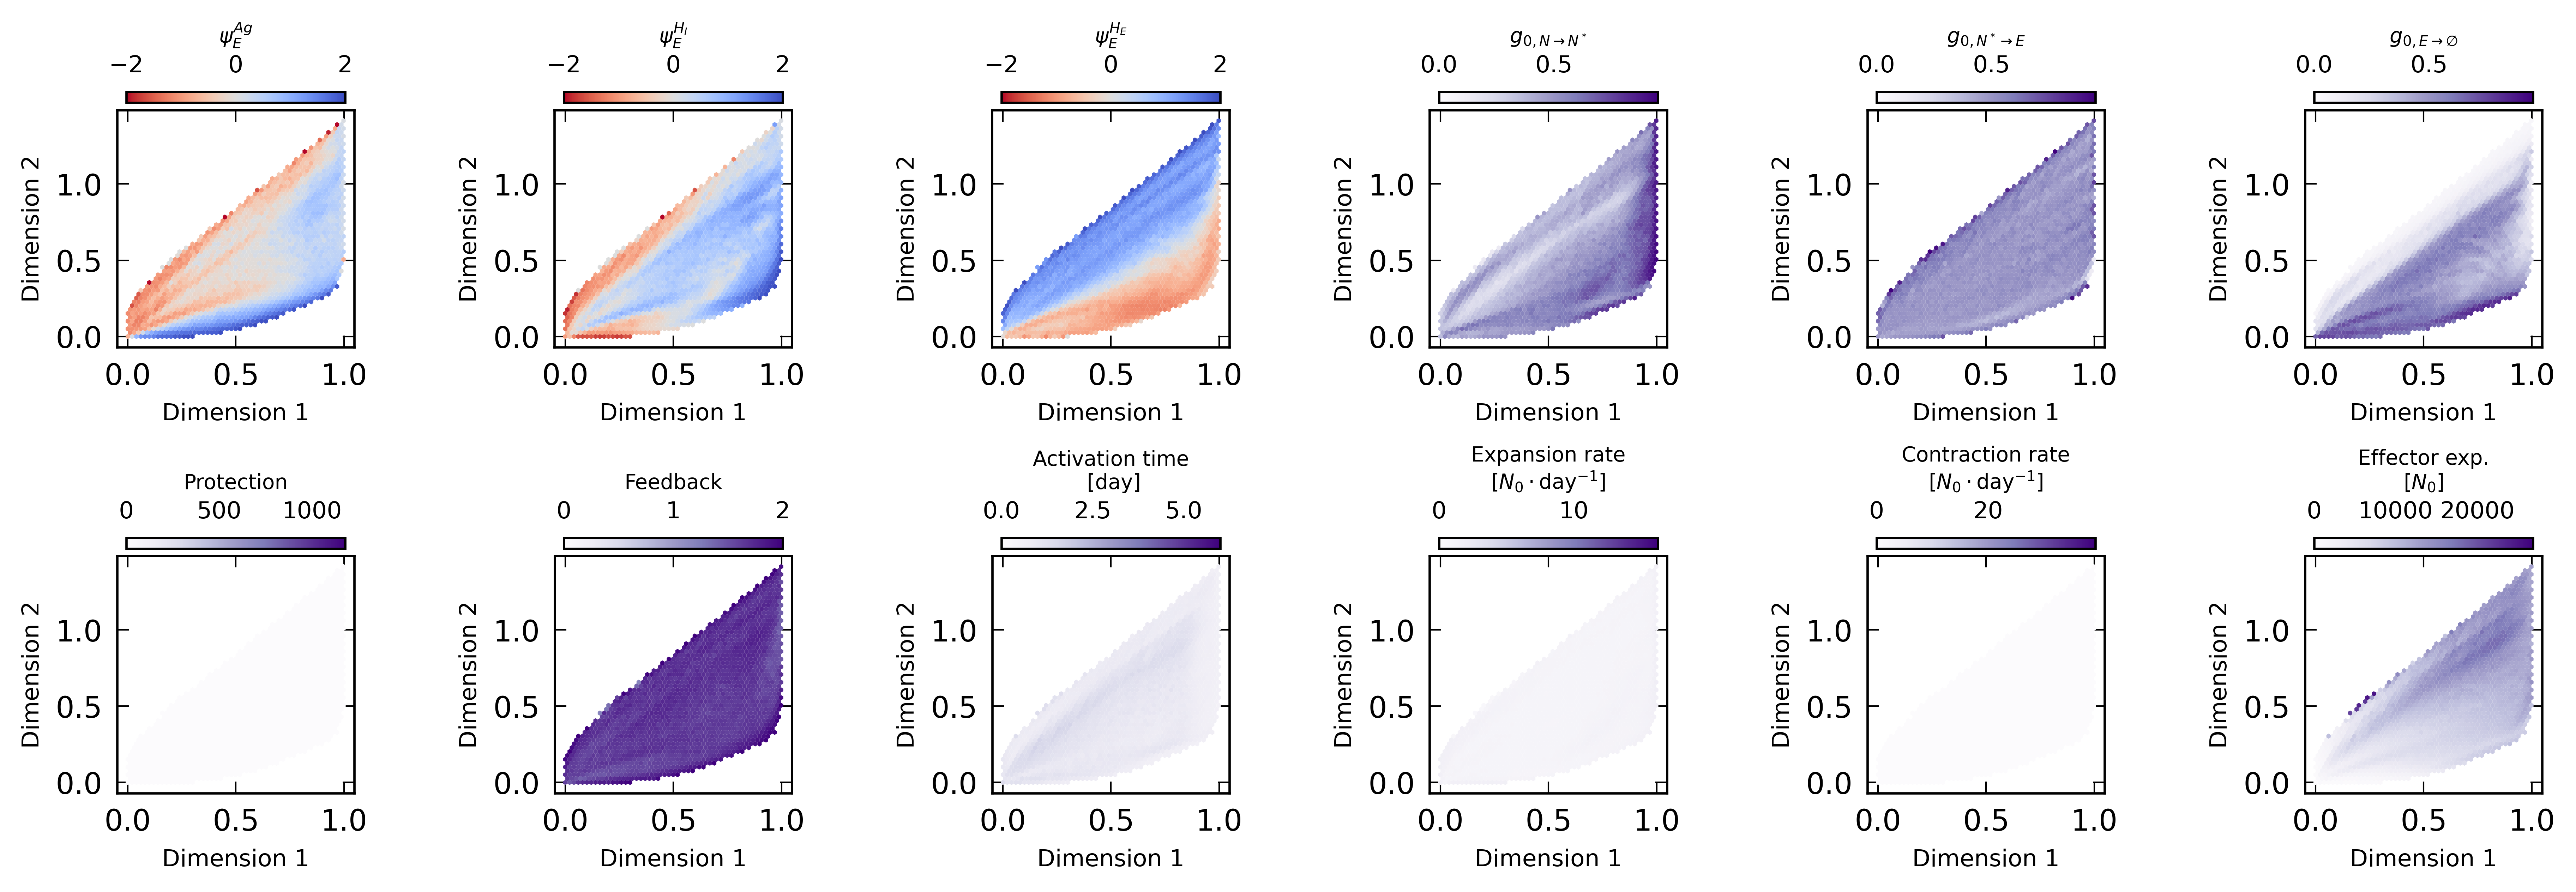

In [7]:
# Create effector trajectory variables
avg_sim_data = use_sim_data.loc[(use_sim_data['b_I'].values > 0.0)*(use_sim_data.d_I > d_S)].groupby(opt_vars, as_index = False).mean()
avg_sim_data.loc[:,'exp_rate'] = np.log(avg_sim_data['max_pE']/max_Na)/np.maximum(avg_sim_data['T_pE_max'] - avg_sim_data['T_pE_start'], t_cycle)
avg_sim_data.loc[:,'end_rate'] = -np.log(avg_sim_data['max_pE']/avg_sim_data['N_0'])/np.maximum(avg_sim_data['T_pE_end'] - avg_sim_data['T_pE_max'], t_cycle)
avg_sim_data.loc[:,'max_exp'] = avg_sim_data['max_pE']/avg_sim_data['N_0']

dyn_vars_for_dim = opt_vars + ['peff_scaled_protection', 'feedback', 'T_pE_start', 'exp_rate', 'end_rate', 'max_exp']
dyn_labels_for_dim = opt_vars_labels + ['Protection', 'Feedback'] + ['Activation time\n [day]', 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Contraction rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Effector exp.\n'+ r'[$N_0$]']

fig, axs = plt.subplots(2,len(opt_vars), figsize = (15,4.5), dpi=300, sharex = True, sharey = True)

for k, ax in enumerate(axs.flat):
    z = avg_sim_data[dyn_vars_for_dim[k]]
    range = np.amax(np.abs(z))
    im = ax.hexbin(avg_sim_data.peff_clearance/avg_sim_data.harm_pI_noprotection, avg_sim_data.peff_toxicity/avg_sim_data.harm_pI_noprotection,
                       gridsize = 50, C = z, linewidths = 0.0,
                   cmap= 'coolwarm_r' if k < 3 else 'Purples',# alpha = 0.8,
                   norm= mpl.colors.Normalize(vmin = -range if k < 3 else 0.0, vmax = range))
                   #norm= mpl.colors.LogNorm() if 'time' in dyn_labels_for_dim[k] else (mpl.colors.Normalize(vmin = -range, vmax = range) if k < 6 else mpl.colors.Normalize()) )

    #ax.set_title(dyn_labels_for_dim[k], fontsize = 7.5)
    ax.set_xlabel('Dimension 1', fontsize = 8)
    ax.set_ylabel('Dimension 2', fontsize = 8)
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.025)
    cb.set_label(dyn_labels_for_dim[k], fontsize = 7)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.6, hspace=0.55)

plt.savefig('_figs/'+comment+'-'+'-reg-average_clear_tox'+'.png', dpi=150, bbox_inches="tight")

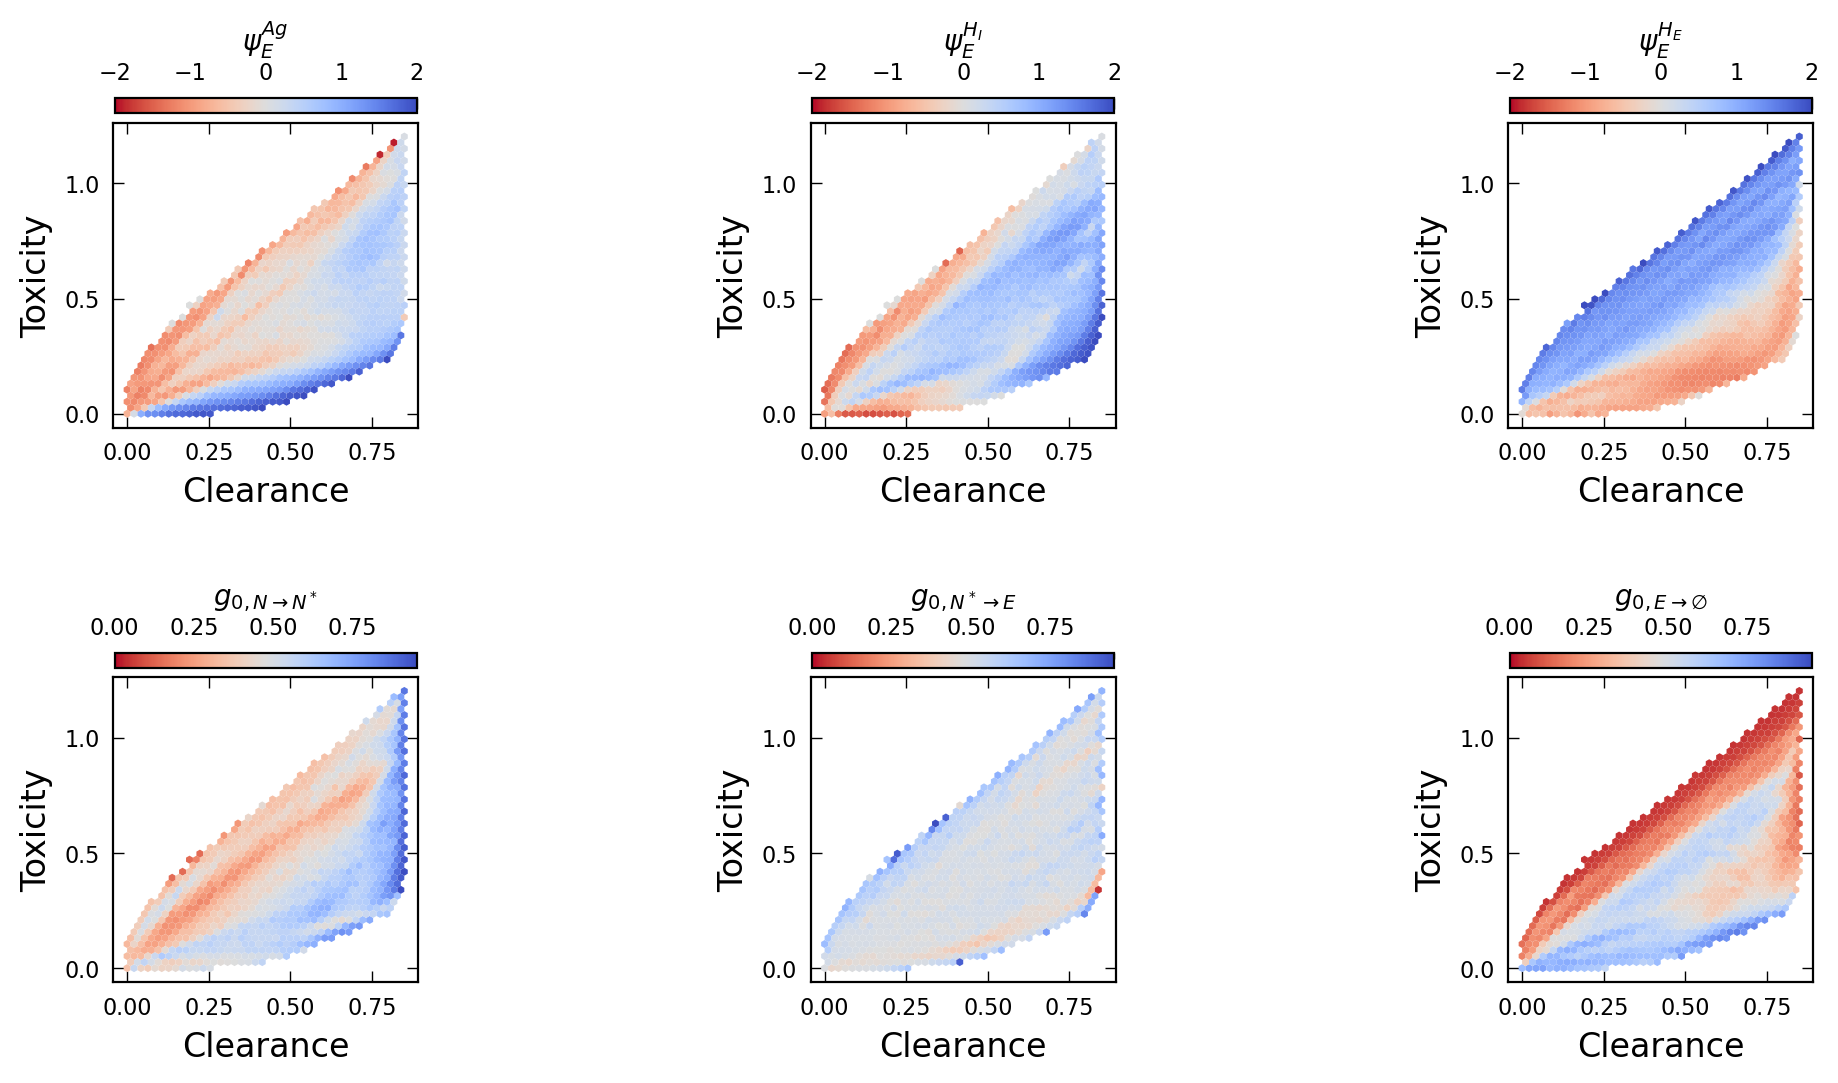

In [8]:
# Visualize pareto regulation
perf_x, perf_y = 1, 2

z_vars = opt_vars
z_var_labels = opt_vars_labels

fig_c, axs = plt.subplots(2, int(np.ceil(len(z_vars)/2)), 
                          figsize=(2*len(z_vars), len(z_vars)), sharex='row', sharey='col')

for j, p in enumerate(z_vars):
    z_varname = p
    z_label = z_var_labels[j]
    z = avg_sim_data[p]
    range = np.amax(np.abs(z))

    x, y = int(j // (np.ceil(len(z_vars)/2))), int(j % (np.ceil(len(z_vars)/2)))
    
    im = axs[x,y].hexbin(avg_sim_data[perf_vars[perf_x]], avg_sim_data[perf_vars[perf_y]],
                       gridsize = 40, C = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8,
                         # reduce_C_function = np.amax,
                   norm = mpl.colors.Normalize(vmin = -range if j < 3 else 0.0, vmax = range))
    # axs[x,y].scatter(data_clear_tox[-2:,0],data_clear_tox[-2:,1], s = 25, marker = "X", c = ["black", "green"])
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=8)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].locator_params(axis='x', nbins=4)

    cb = fig_c.colorbar(im, ax=axs[x,y], location='top', shrink = 0.65, pad = 0.025)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig_c.subplots_adjust(wspace=.5, hspace=0.5)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(perf_labels[perf_x], fontsize = 12)
    ax.set_ylabel(perf_labels[perf_y], fontsize = 12)

plt.savefig('_figs/'+comment+'-reg-average_clear_tox'+'.png', dpi=150, bbox_inches="tight")

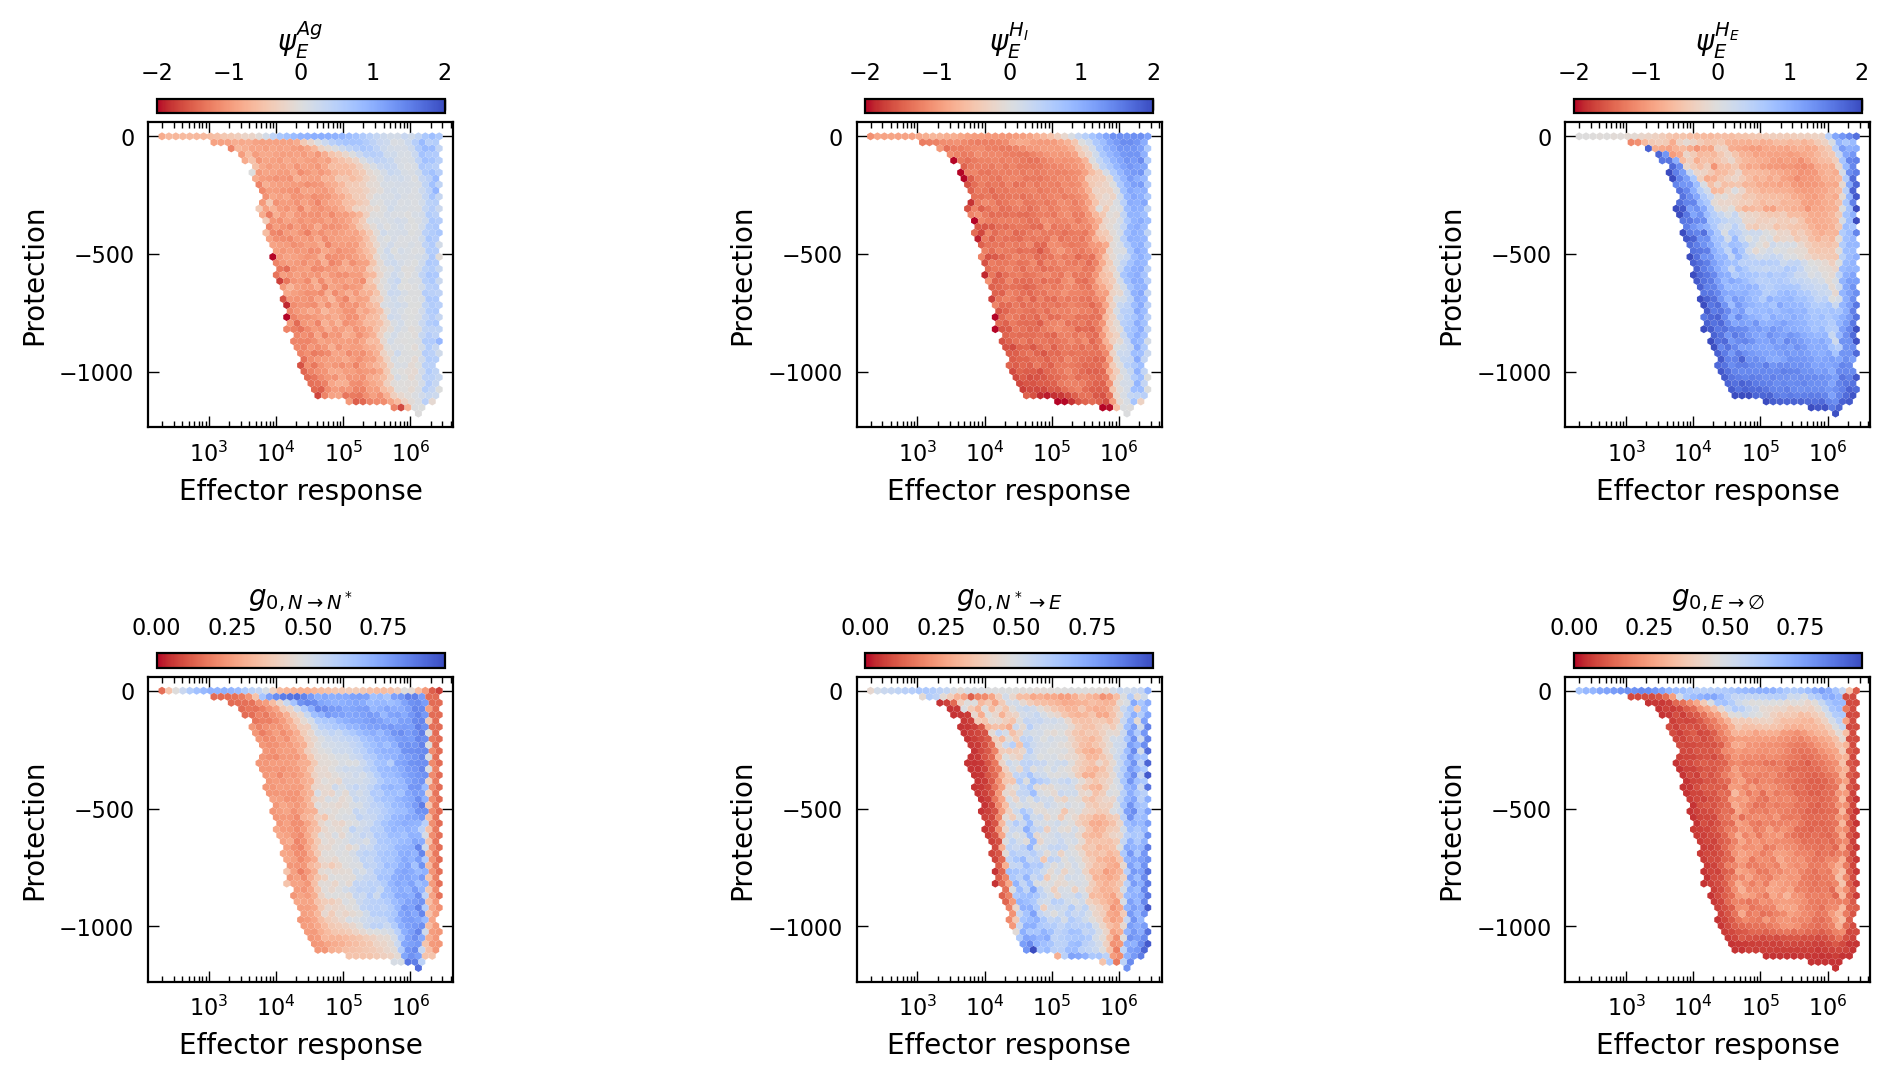

In [9]:
# Visualize pareto regulation
z_vars = opt_vars
z_var_labels = opt_vars_labels
perf = 0

fig_c, axs = plt.subplots(2, int(np.ceil(len(z_vars)/2)), 
                          figsize=(2*len(z_vars), len(z_vars)), sharex='row', sharey='col')

for j, p in enumerate(z_vars):
    z_varname = p
    z_label = z_var_labels[j]
    z = avg_sim_data[p]
    range = np.amax(np.abs(z))

    x, y = int(j // (np.ceil(len(z_vars)/2))), int(j % (np.ceil(len(z_vars)/2)))
    
    im = axs[x,y].hexbin(avg_sim_data['max_pE'], avg_sim_data[perf_vars[perf]],
                       gridsize = 40, C = avg_sim_data[p], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8,
                         xscale ='log',
                   norm = mpl.colors.Normalize(vmin =  -range if j < 3 else 0.0, vmax = range))
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=8)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].semilogx()
    #axs[x,y].locator_params(axis='x', nbins=4)

    cb = fig_c.colorbar(im, ax=axs[x,y], location='top', shrink = 0.65, pad = 0.025)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig_c.subplots_adjust(wspace=.6, hspace=0.5)

for k, ax in enumerate(axs.flat):
    ax.set_ylabel(perf_labels[perf], fontsize = 10)
    ax.set_xlabel(r"Effector response", fontsize = 10)

#plt.savefig('_figs/'+comment+'-reg-average_clear_feedback'+'.png', dpi=150, bbox_inches="tight")

#### Optimize $[\text{Clearance}]$

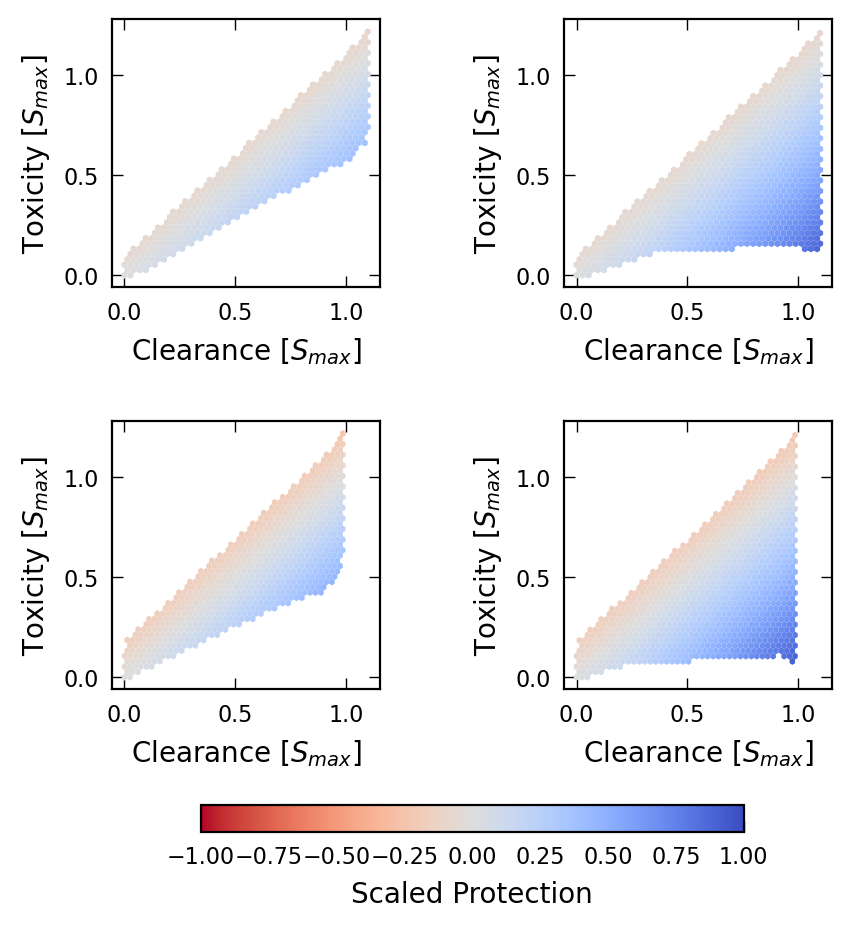

In [10]:
# Visualize pareto regulation
perf_x, perf_y = 1, 2

fig, axs = plt.subplots(2, 2, 
                          figsize=(5, 6), sharex=True, sharey=True)

# vmin = np.amin(use_sim_data.peff_scaled_protection)
# vmax = np.amax(use_sim_data.peff_scaled_protection)
# range = np.maximum(np.abs(vmin), np.abs(vmax))

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    z_label = r"Scaled Protection"

    y, x = k % 2, k // 2
    
    im = axs[x,y].hexbin(data.peff_clearance, data.peff_toxicity,
                       gridsize = 40, C = data.peff_scaled_protection,
                         cmap='coolwarm_r', edgecolors = 'None',
                   norm = mpl.colors.Normalize(vmin = -1, vmax = 1))
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=8)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].locator_params(axis='x', nbins=4)

    # if k == 1:
    #     cb = fig.colorbar(im, ax=axs[x,y], location='right', shrink = 0.85, pad = 0.25)
    #     cb.set_label(z_label, fontsize = 10)
    #     cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.4, hspace=0.5)
cb = fig.colorbar(im, ax=axs.ravel().tolist(), location = 'bottom', pad = 0.125, shrink = 0.7)
cb.set_label(z_label, fontsize = 10)
cb.ax.tick_params(labelsize=8)

for j, ax in enumerate(axs.flat):
    ax.set_xlabel(perf_labels[perf_x] + r' [$S_{max}$]', fontsize = 10)
    ax.set_ylabel(perf_labels[perf_y] + r' [$S_{max}$]', fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    #ax.set_title(quadrants_labels[j], fontsize = 8.0, pad = 2.5)

plt.savefig('_figs/'+comment+'-reg-singles_clear_tox'+'.png', dpi=150, bbox_inches="tight")

##### Optimize protection for each infection

In [11]:
# Find optimal designs for each infection by grid searching
grid_opt = pd.concat(Parallel(n_jobs = num_cpu,
                          batch_size = 1)(delayed(grid_search)(g)
                                                   for (_, g) in use_sim_data.groupby(vir_vars)
                                                  ))

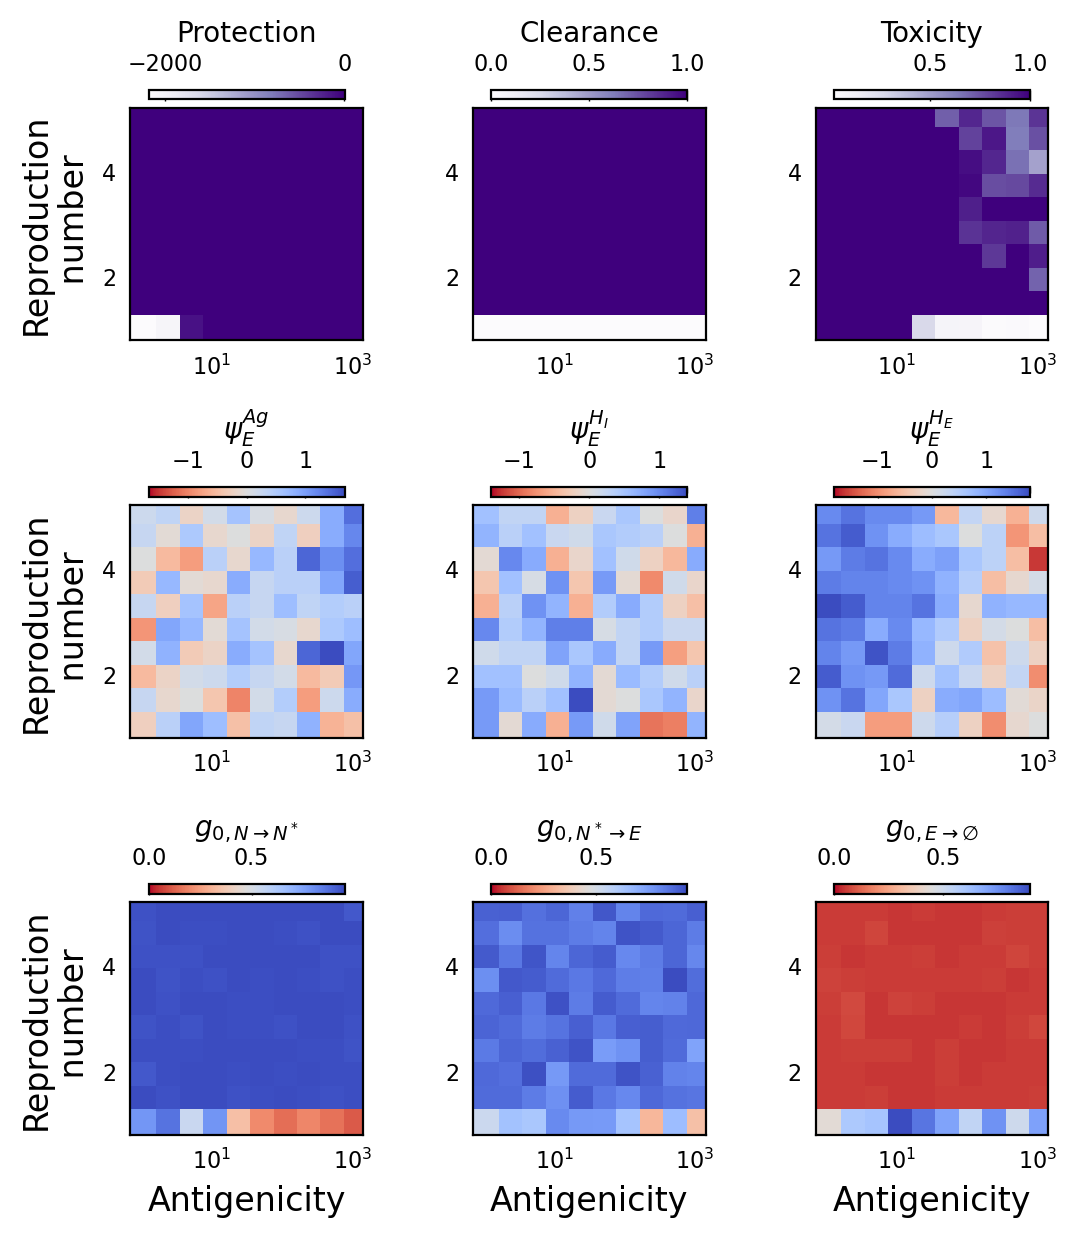

In [12]:
# Visualize optimal protection and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 1)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 12)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 12)
    
    z_label = (perf_labels[0:3] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

plt.savefig('_figs/'+comment+'-reg-singles_clearance_feedback_reg_hmap'+'.png', dpi=300, bbox_inches="tight")

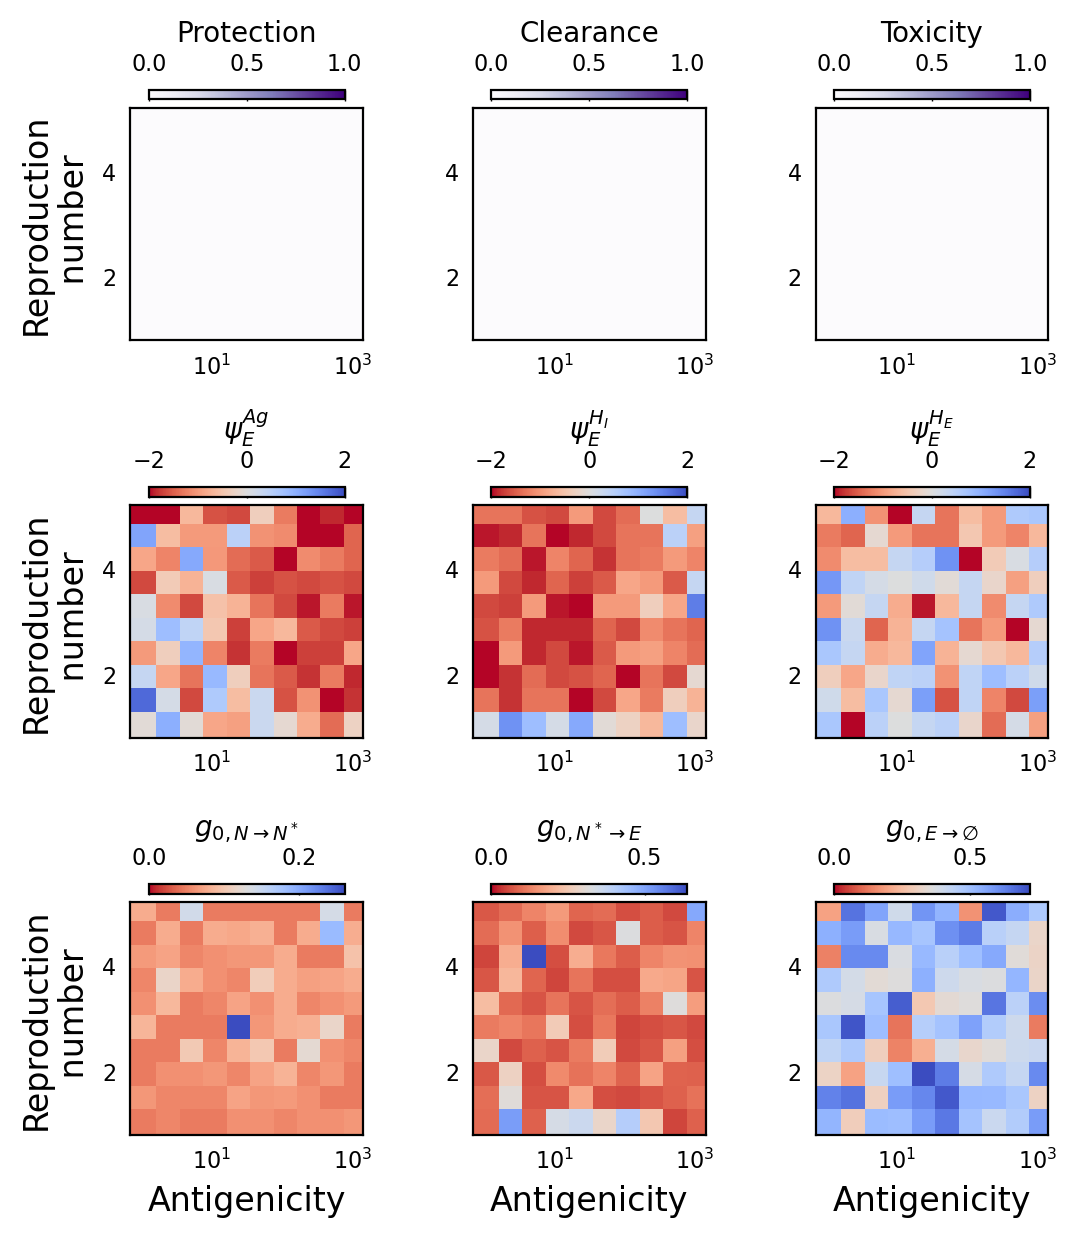

In [13]:
# Visualize optimal protection and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 2)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    # for i, c in enumerate([2]):
    #     ax.tricontour(cluster_input['S_0']/cluster_input[plots[0]], 
    #                   1.0*cluster_input[plots[1]], 
    #                  cluster_input['phase_cluster'] == c, levels = [0,1], linewidths=2.0, colors='yellow')
        
    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 12)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 12)
    
    z_label = (perf_labels[0:3] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

plt.savefig('_figs/'+comment+'-reg-singles_toxicity_feedback_reg_hmap'+'.png', dpi=300, bbox_inches="tight")

/tmp/ipykernel_77226/356489581.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_input.loc[:,'phase_cluster'] = clustering.labels_


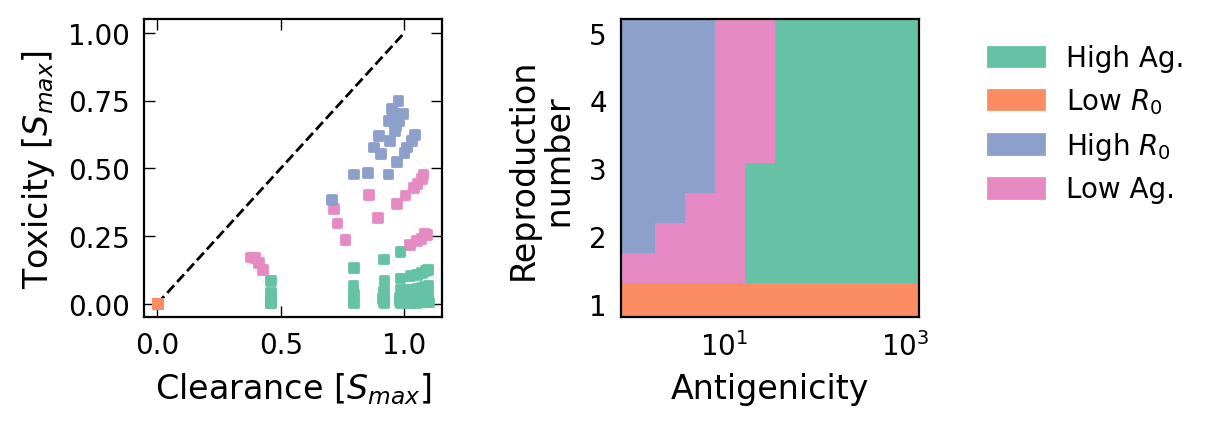

In [14]:
fig, axs = plt.subplots(1, 2, 
                          figsize=(5, 2), sharex=False, sharey=False)

size = 1000/np.cbrt(n_virs)
cluster_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']# + cmap_colors[-2:]

cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)]
clustering = KMeans(n_clusters=4, n_init = 10,
        random_state=0).fit(cluster_input[['peff_clearance', 'peff_toxicity']].values/cluster_input.harm_pI_noprotection.values[:, np.newaxis])

# clustering = KMeans(n_clusters=4, n_init = 10,
#         random_state=0).fit(cluster_input[opt_vars].values/(np.amax(avg_sim_data[opt_vars].values, axis = 0) - np.amin(avg_sim_data[opt_vars].values, axis = 0)))

cluster_input.loc[:,'phase_cluster'] = clustering.labels_

axs[0].scatter(cluster_input.peff_clearance, 
           cluster_input.peff_toxicity,
           c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
           marker = 's',
           s = 10)
axs[0].plot(np.linspace(0,1.), np.linspace(0,1.), color = 'black', linestyle = '--', zorder = 0)
# axs[0].set_xscale('symlog')
# axs[0].set_yscale('symlog')

axs[0].set_xlabel(r'Clearance [$S_{max}$]', fontsize = 12)
axs[0].set_ylabel(r'Toxicity [$S_{max}$]', fontsize = 12)

axs[1].scatter(S_0/cluster_input[plots[0]], cluster_input[plots[1]],
                 marker ='s', s = size, 
                c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values], 
                 edgecolors = 'None')

axs[1].set_xlabel(plot_labels[0], fontsize = 12)
axs[1].set_ylabel(plot_labels[1], fontsize = 12)
axs[1].semilogx()

legend_handles = []
phase_clusters = np.unique(cluster_input['phase_cluster'].values)
phase_cluster_labels = ["High Ag.", r"Low $R_0$", "High $R_0$", "Low Ag."]
n_clusters = len(phase_clusters)
for key, color in enumerate([cluster_colors[i] for  i in phase_clusters]):
    patch = mpatches.Patch(color=color, label=str(phase_cluster_labels[key]))
    legend_handles.append(patch)

axs[1].legend(handles=legend_handles, bbox_to_anchor=(1.15, 1.0), fontsize=10, framealpha=0, ncol = 1)

fig.subplots_adjust(wspace=0.6, hspace=0.35)

for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()

plt.savefig('_figs/'+comment+'-optimal-reg_hmap'+'.png', dpi=300, bbox_inches="tight")

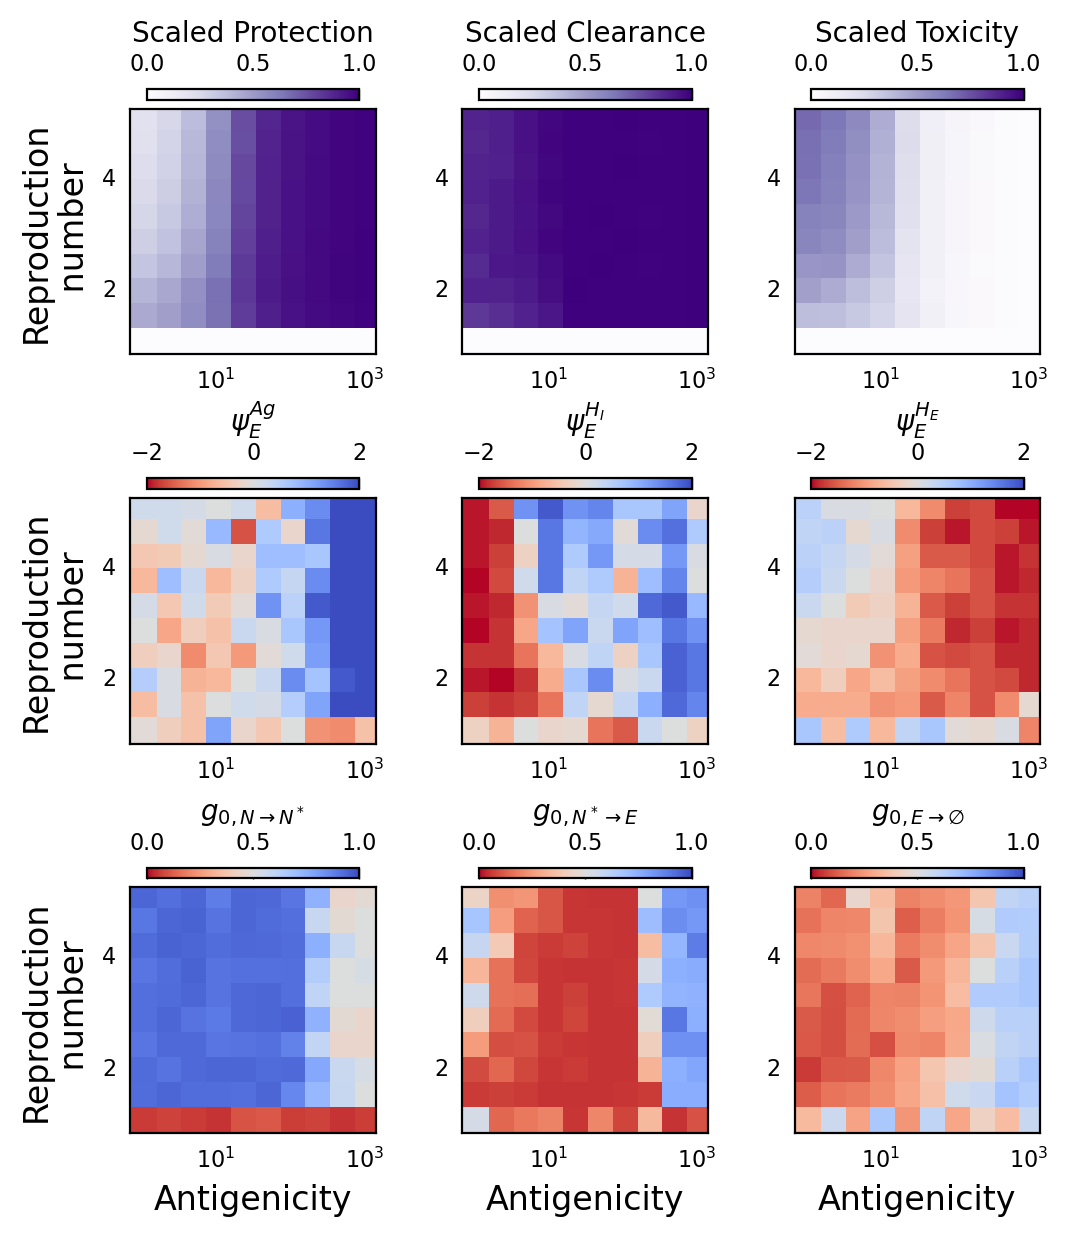

In [15]:
# Visualize optimal protection and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 0)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    # ax.tricontour(cluster_input['S_0']/cluster_input[plots[0]], 
    #               1.0*cluster_input[plots[1]], 
    #              cluster_input['phase_cluster'], levels = phase_clusters, linewidths=2.0, colors=cluster_colors)
        
    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range if k < 6 else 1.0))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 12)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 12)
    
    z_label = (['Scaled ' + perf_labels[0], 'Scaled ' + perf_labels[1], 'Scaled ' + perf_labels[2]] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/'+comment+'-reg-singles_prot_strong_feedback_reg_hmap'+'.png', dpi=300, bbox_inches="tight")

The optimal response depends on the antigenicity of the pathogens encountered. The optimal design of the response to high antigenicity pathogens demonstrates the logic that the system should be tuned to respond to threats that it can easily detect.

In [16]:
# Add cluster information to data
cluster_sim_df = use_sim_data.merge(cluster_input[plots + ['phase_cluster']], how = 'left', on = plots)

##### Relationship between feedback strength and performance

In [17]:
# Compute optimal performance as a function of allowed feedback strength
feedback_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'feedback', include = ['phase_cluster'])
                                                   for (_, g) in cluster_sim_df.groupby(vir_vars)
                                                  ))

cluster_feedback_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'feedback', include = ['phase_cluster'])
                                                   for (_, g) in cluster_sim_df.groupby(['phase_cluster'])
                                                  ))

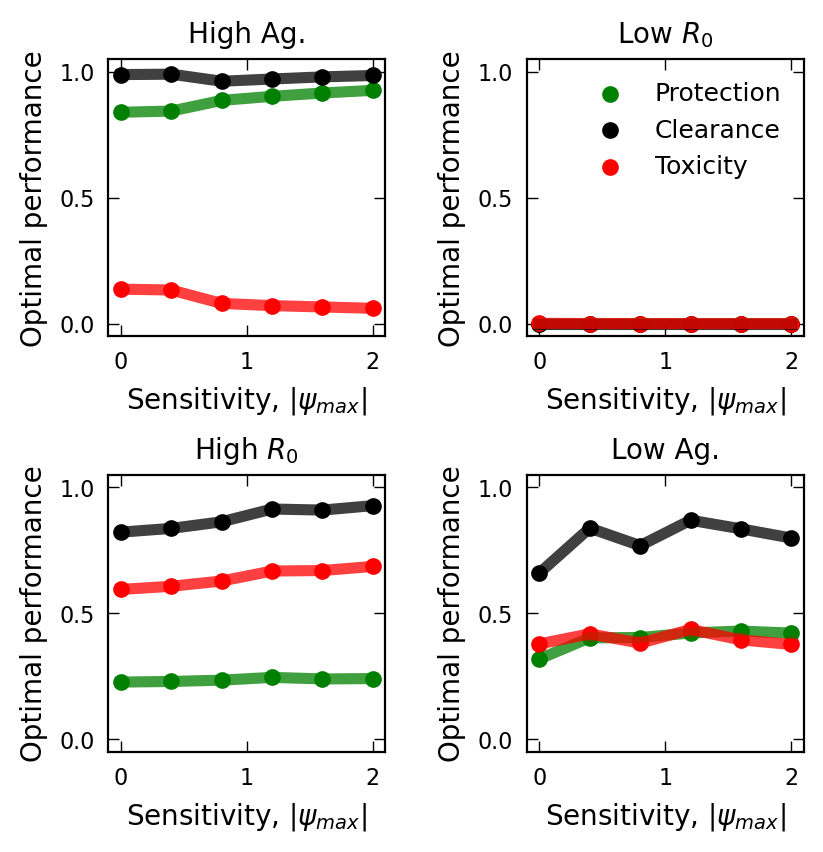

In [18]:
# Make trade-off figure
fig, axs = plt.subplots(int(np.ceil(n_clusters/2)),2, figsize=(n_clusters +1/2, n_clusters + 1/2), sharex='row', sharey='col') #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, perf in enumerate(perf_vars[0:3]):
        axs.flat[k].plot(g['feedback'].values,
             g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
             color = perf_var_colors[i],
                            **kwargs)
    
        axs.flat[k].scatter(g['feedback'].values,
         g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
         color = perf_var_colors[i], 
         label = perf_labels[i])

    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)

for ax in axs.flat: 
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Optimal performance", fontsize = 10)
    ax.set_xlabel(r"Sensitivity, $|\psi_{max}|$", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/'+comment+'-pareto-prot_feedback'+'.png', dpi=300, bbox_inches="tight")

In the high protection setting, the primary benefit if a feedback response is controlling the toxicity of the response.

/tmp/ipykernel_77226/394726654.py:12: RuntimeWarning: invalid value encountered in divide
  g[stim].values/normalize,
/tmp/ipykernel_77226/394726654.py:17: RuntimeWarning: invalid value encountered in divide
  g[stim].values/normalize,


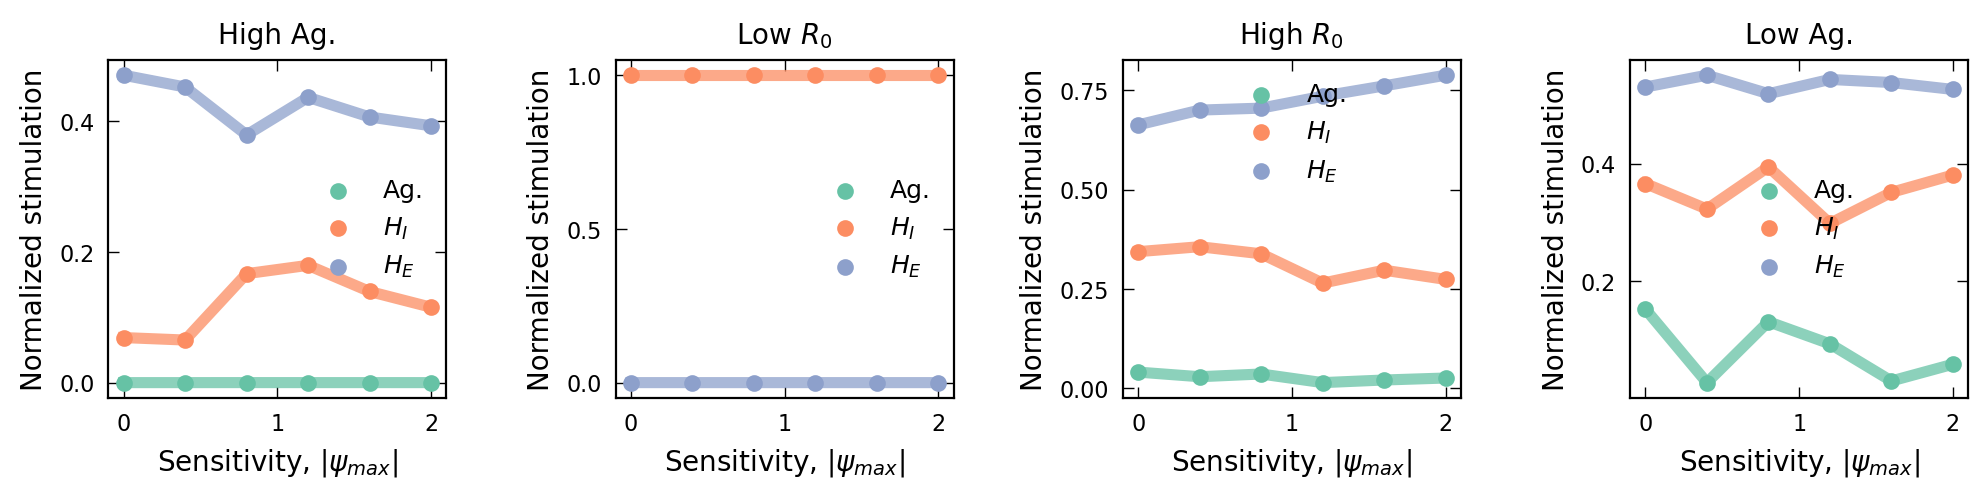

In [19]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, stim in enumerate(stim_vars):
        normalize = np.amax(cluster_sim_df.loc[(cluster_sim_df.phase_cluster == k), stim])
        axs[k].plot(g['feedback'].values,
             g[stim].values/normalize,
             color = cmap_colors[i],
                            **kwargs)
    
        axs[k].scatter(g['feedback'].values,
         g[stim].values/normalize,
         color = cmap_colors[i], 
         label = ['Ag.', r'$H_I$', r'$H_E$'][i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Normalized stimulation", fontsize = 10)
    ax.set_xlabel("Sensitivity, $|\psi_{max}|$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-prot_stim_feedback'+'.png', dpi=150, bbox_inches="tight")

Paradoxically, for a response to be protective, it drives down the infection feedback signals.

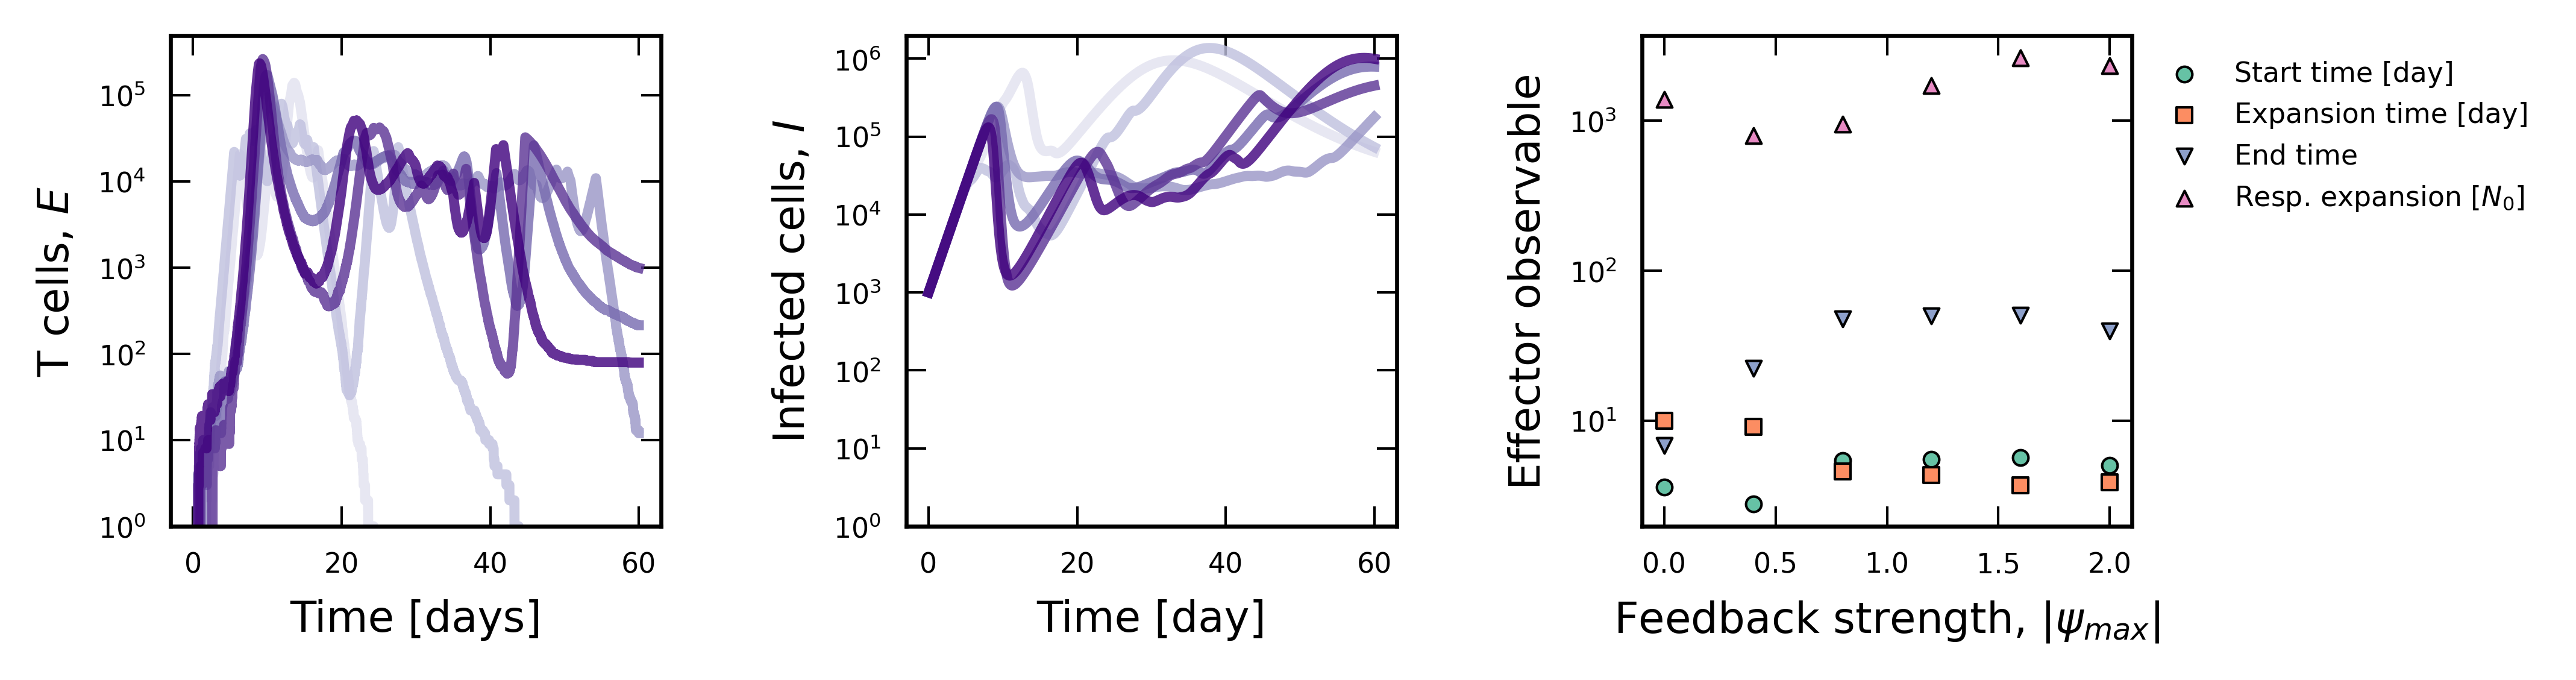

In [20]:
# Plot select infection responses
fig, axs = plt.subplots(1,3, dpi = 300, sharex = False, sharey = False, figsize=(7, 2))

data = cluster_input.loc[(cluster_input.phase_cluster == 0)].reset_index()
v = data.loc[data[['peff_scaled_protection']].idxmin(), vir_vars].values.ravel()
ps = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == 0)*(cluster_feedback_grid_opt.phase_cluster == 0), opt_vars[0:3] + reg_bl + ['feedback']].values
store_runs = []
# Loop and do 
for k, p in enumerate(ps):
    # if k % 10 == 0:
    # Vary pareto designs
    feedback = p[-1]
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[6],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              K_S = v[5],
                              NE_regulation = [p[0], p[1], p[2], p[4]],
                              activation_regulation = [p[0], p[1], p[2], p[3]],
                              contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 2.0*sim_duration,
                              steps = 4.0*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0].plot(ts, E, linewidth=2.0, color = plt.cm.Purples(0.2 + 0.8*feedback/psi_max), alpha = 0.8)
    axs[1].plot(ts, I, linewidth=2.0, color = plt.cm.Purples(0.2 + 0.8*feedback/psi_max), alpha = 0.8)
    axs[2].scatter(feedback, sim_summary[7], color = cmap_colors[0], linewidths = 0.5,
                          marker = reg_markers[0], s = 9.5, ec = 'black', label = 'Start time [day]' if k == 0 else '') #Effector start time
    axs[2].scatter(feedback, sim_summary[6] - sim_summary[7], color = cmap_colors[1], linewidths = 0.5,
                          marker = reg_markers[1], ec = 'black', s = 9.5, label = 'Expansion time [day]' if k == 0 else '') # Effector peak time
    axs[2].scatter(feedback, (sim_summary[10] - sim_summary[6]), color = cmap_colors[2], linewidths = 0.5,
                          marker = reg_markers[2], ec = 'black', s = 9.5, label = 'End time' if k == 0 else '') # Effector end time
    axs[2].scatter(feedback, np.amax(E)/v[4], color = cmap_colors[3], linewidths = 0.5,
                          marker = reg_markers[3], ec = 'black', s = 9.5, label = r'Resp. expansion [$N_0$]' if k == 0 else '') # Effector peak magnitude

    store_runs.append( (p.tolist() + [sim_summary[7], sim_summary[6] - sim_summary[7], sim_summary[10] - sim_summary[6], np.amax(E)/v[4], sim_summary[8]/v[4], sim_summary[9]]) )

axs[2].legend(bbox_to_anchor=(1., 1), fontsize=5.5, framealpha=0)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j == 0:
        ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [days]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    elif j == 1:
        ax.set_ylabel(r'Infected cells, $I$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    else:
        ax.set_xlabel("Feedback "+ r"strength, $|\psi_{max}|$", fontsize = 8.5)
        #ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector observable", fontsize = 8.5)
        ax.set_yscale('symlog')

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-design-feedback_prot-eff-dynamics'+'.png', dpi=150, bbox_inches="tight")

##### Relationship between design and performance

In [21]:
# Compute optimal performance as a function of each individual single design 
ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'ablate', include = ['phase_cluster'])
                                                   for (_, g) in cluster_sim_df.groupby(vir_vars)
                                                  ))

cluster_ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'ablate', include = ['phase_cluster'])
                                                   for (_, g) in cluster_sim_df.groupby(['phase_cluster'])
                                                  ))

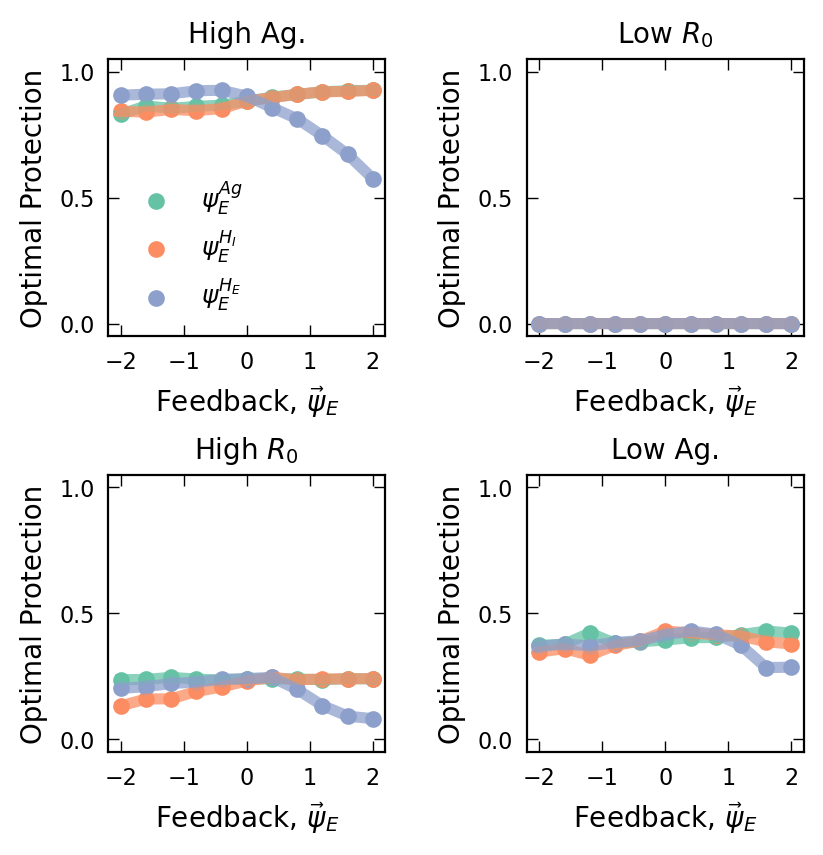

In [22]:
# Make trade-off figure
fig, axs = plt.subplots(int(np.ceil(n_clusters/2)),2, figsize=(n_clusters +1/2, n_clusters + 1/2), sharex=False, sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on clearance
    for i, var in enumerate(opt_vars[0:3]):
        axs.flat[k].plot(g.loc[(g.ablate_index == i),  [var]].values,
             g.loc[(g.ablate_index == i), [perf_vars[perf]]].values,
             color = cmap_colors[i], 
                            **kwargs)

        axs.flat[k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
                            g.loc[(g.ablate_index == i), [perf_vars[perf]]].values,
                            label = opt_vars_labels[i],
                            color = cmap_colors[i])

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[0].legend(fontsize=9, framealpha=0, ncol = 1)
axs.flat[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_ylim(-0.05, 1.05)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=6)
    ax.set_ylabel("Optimal Protection", fontsize = 10)
    if j // n_clusters == 0:
        ax.set_xlabel(r"Feedback, $\vec\psi_E$", fontsize = 10)
    else:
        ax.set_xlabel("Baseline\n" +r"regulation, $\vec g_0$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/'+comment+'-pareto-prot_ablate_feedback'+'.png', dpi=300, bbox_inches="tight")

In [23]:
# # Make trade-off figure
# fig, axs = plt.subplots(2, n_clusters,figsize=(2.5*n_clusters, 5), sharex='row', sharey='col') #,layout='constrained')
# perf = 0

# kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
# data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

# for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

#     # (a) Effect of single parameter ablation on clearance
#     for i, var in enumerate(opt_vars):
#         if i <= 2:
#             axs[0,k].plot(g.loc[(g.ablate_index == i),  [var]].values,
#                  g.loc[(g.ablate_index == i), [perf_vars[perf]]].values,
#                  color = cmap_colors[i], 
#                  label = opt_vars_labels[i],
#                                 **kwargs)

#             axs[0, k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
#                  g.loc[(g.ablate_index == i), [perf_vars[perf]]].values,
#                  color = cmap_colors[i])
    
#         else:
#             axs[1,k].plot(g.loc[(g.ablate_index == i),  [var]].values,
#                  g.loc[(g.ablate_index == i), [perf_vars[perf]]].values,
#                  color = cmap_colors[i], 
#                  label = opt_vars_labels[i],
#                                 **kwargs)

#             axs[1, k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
#              g.loc[(g.ablate_index == i), [perf_vars[perf]]].values,
#              color = cmap_colors[i])

#     axs[0,k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
#     axs[0,k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
# axs[0, -1].legend(bbox_to_anchor=(1.1, 1), fontsize=9, framealpha=0, ncol = 1)
# axs[1, -1].legend(bbox_to_anchor=(1.1, 1), fontsize=9, framealpha=0, ncol = 1)
    
# for j, ax in enumerate(axs.flat):
#     ax.minorticks_off()
#     #ax.set_ylim(None, 1)
#     ax.set_box_aspect(1)
#     ax.tick_params(axis='both', which='major', labelsize=8)
#     ax.locator_params(axis='y', nbins=4)
#     ax.locator_params(axis='x', nbins=6)
#     ax.set_ylabel("Optimal Protection", fontsize = 10)
#     if j // n_clusters == 0:
#         ax.set_xlabel("Feedback\n"+ r"effect, $\vec\psi_E$", fontsize = 10)
#     else:
#         ax.set_xlabel("Baseline\n" +r"regulation, $\vec g_0$", fontsize = 10)

# fig.subplots_adjust(wspace=.75, hspace=0.45)

# plt.savefig('_figs/'+comment+'-pareto-prot_ablate_feedback'+'.png', dpi=300, bbox_inches="tight")

Suggests that antigen and infection harm detection are fingible (once a response has been inititated).

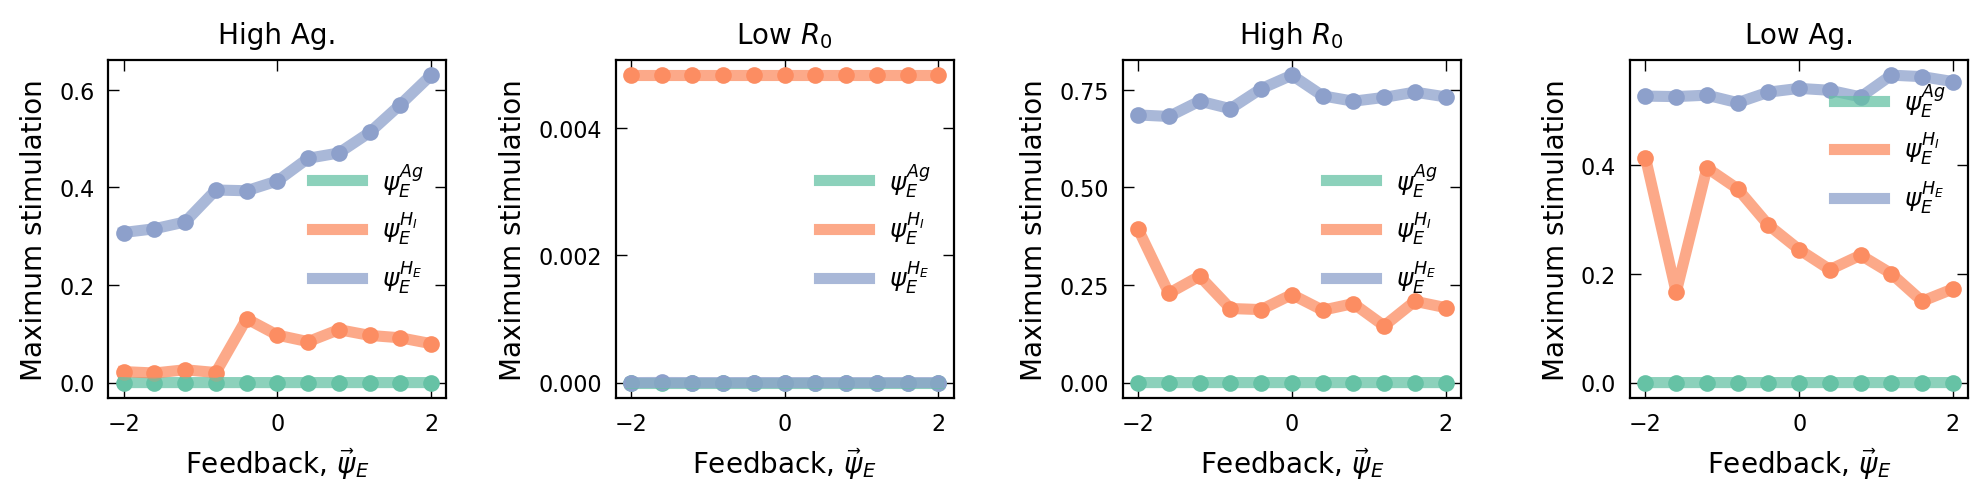

In [24]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    # (a) Effect of single parameter ablation on clearance
    normalize = np.amax(cluster_sim_df.loc[(cluster_sim_df.phase_cluster == k), stim])
    for i, var in enumerate(opt_vars):
        if i <= 2:
            axs[k].plot(g.loc[(g.ablate_index == i),  [var]].values,
                 g.loc[(g.ablate_index == i), [stim_vars[i]]].values/normalize,
                 color = cmap_colors[i], 
                 label = opt_vars_labels[i],
                                **kwargs)

            axs[k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
                 g.loc[(g.ablate_index == i), [stim_vars[i]]].values/normalize,
                 color = cmap_colors[i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Maximum stimulation", fontsize = 10)
    ax.set_xlabel(r"Feedback, $\vec\psi_E$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-prot_stim_ablate'+'.png', dpi=150, bbox_inches="tight")

Figure above shows sensitive control with the anti-inflammatory signal is required to achieve high levels of protection. Also, non-monotonic dependence on the activation pathway is observed.

The region of low sensitivity to the anti-inflammatory signal corresponds to biologically observed designs. In particular, it can be seen to drive the optima of the other design variables. Can I show this with correlations? What do we get out of looking at the baseline designs?

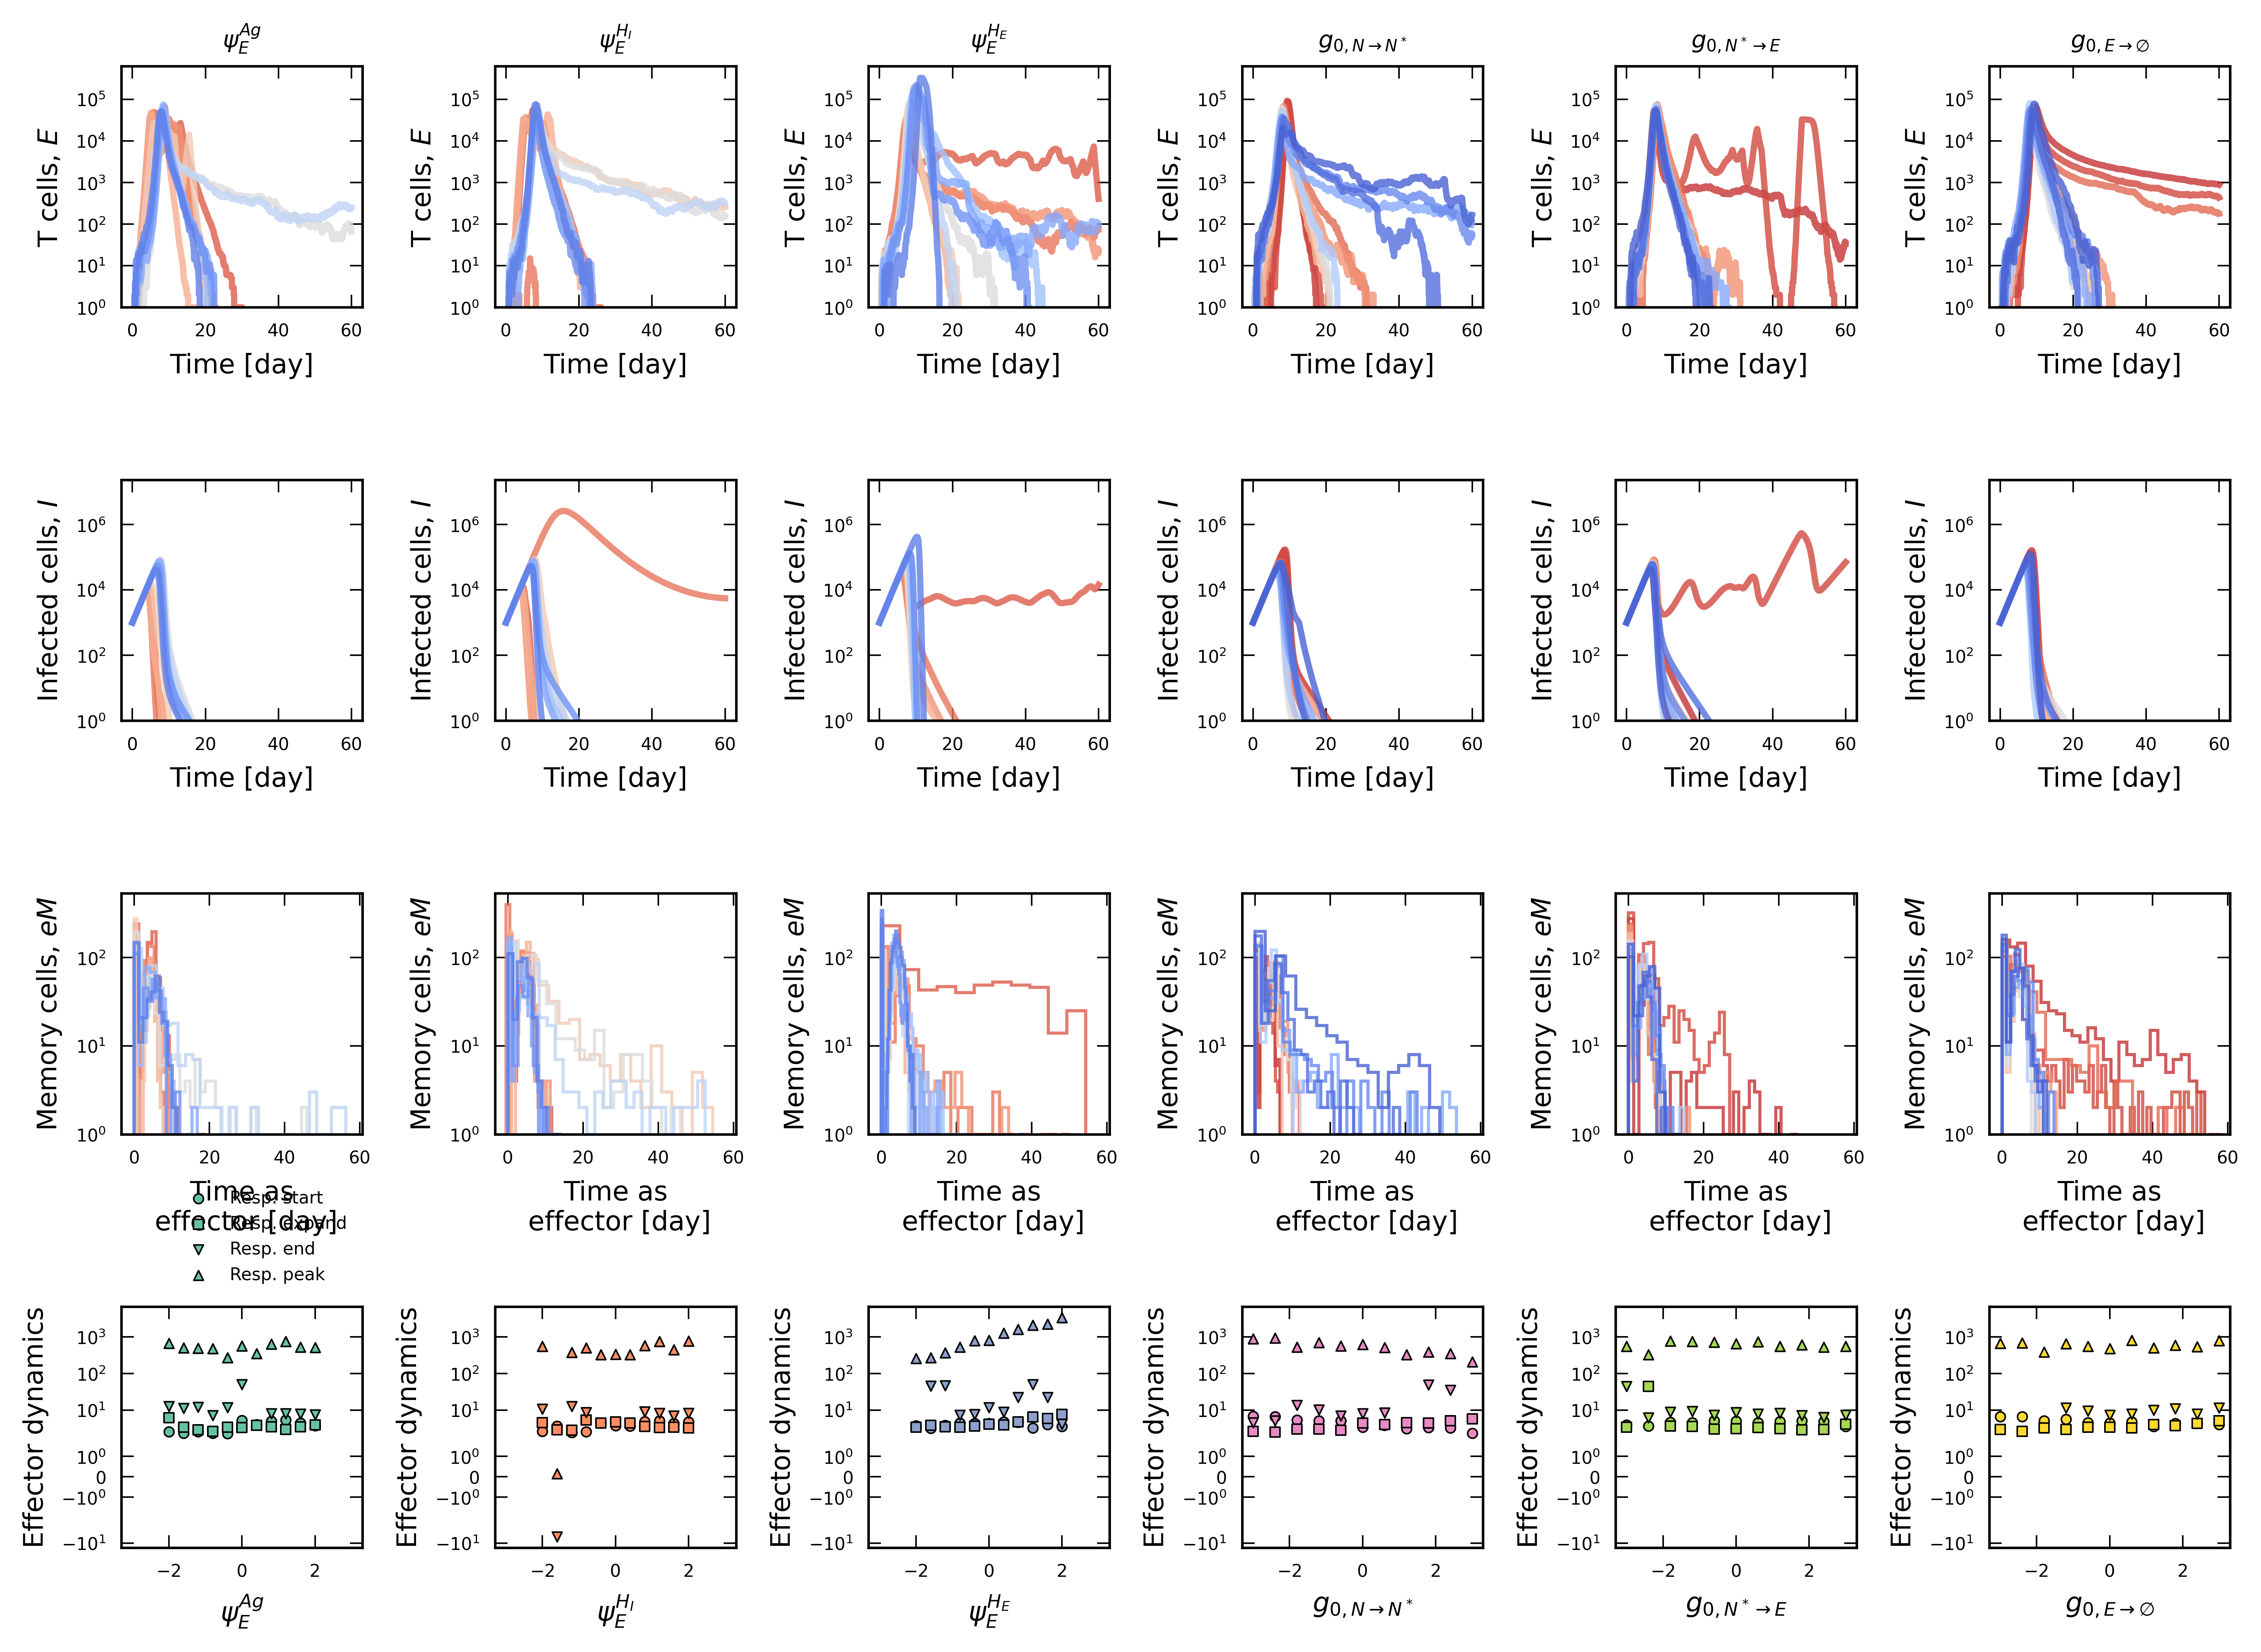

In [25]:
# Plot select infection responses
fig, axs = plt.subplots(4,len(opt_vars), dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*len(opt_vars), 9))

data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.phase_cluster == 0)].reset_index()
v = data.loc[data[['peff_scaled_protection']].idxmin(), vir_vars].values.ravel()
ps = data[opt_vars[0:3] + reg_bl + ['ablate_index']].values
store_Es = []
store_Is = []

# Loop and do 
for k, p in enumerate(ps):
    # if (k % n_steps) % 4 == 0:
    # Vary pareto designs
    index = int(p[-1])
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[6],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              K_S = v[5],
                              NE_regulation = [p[0], p[1], p[2], p[4]],
                              EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -2.5*L0_max],
                              activation_regulation = [p[0], p[1], p[2], p[3]],
                              contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 2.0*sim_duration,
                              steps = 4.0*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    T_pEcytM = data_dict["pmemory_formed"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0, index].plot(ts, E, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
    axs[1, index].plot(ts, I, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
    axs[2, index].hist(T_pEcytM, bins = 'auto', histtype='step', color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8);
    axs[3, index].scatter(p[index], sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[0], s = 9.5, ec = 'black', label = 'Resp. start' if k == 0 else '') #Effector start time
    axs[3, index].scatter(p[index], sim_summary[6] - sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[1], ec = 'black', s = 9.5, label = 'Resp. expand' if k == 0 else '') # Effector peak time
    axs[3, index].scatter(p[index], (sim_summary[10] - sim_summary[6]) if (E[-1] < N_0) else np.nan, color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[2], ec = 'black', s = 9.5, label = 'Resp. end' if k == 0 else '') # Effector end time
    axs[3, index].scatter(p[index], np.amax(E)/v[4], color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[3], ec = 'black', s = 9.5, label = 'Resp. peak' if k == 0 else '') # Effector peak magnitude
    
    axs[0, index].set_title(opt_vars_labels[index], fontsize = 7.5)
    if index == 2:
        store_Es.append(E)
        store_Is.append(I)

axs[3, 0].legend(bbox_to_anchor=(1.0, 1.55), fontsize=5.5, framealpha=0, ncol = 1)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j // len(opt_vars) == 0:
        ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    elif j // len(opt_vars) == 1:
        ax.set_ylabel(r'Infected cells, $I$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    elif j // len(opt_vars) == 2:
        ax.set_ylabel(r'Memory cells, $eM$', fontsize = 8.5)
        ax.set_xlabel("Time as\n effector [day]", fontsize = 8.5)
        #ax.semilogx()
        ax.semilogy()
        ax.set_ylim(1,)
    else:
        ax.set_xlabel(opt_vars_labels[j % len(opt_vars)], fontsize = 8.5)
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector dynamics", fontsize = 8.5)
        ax.set_yscale('symlog')

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.55, hspace=0.25)

plt.savefig('_figs/'+comment+'-pareto-design-ablate_prot-eff-dynamics'+'.png', dpi=300, bbox_inches="tight")

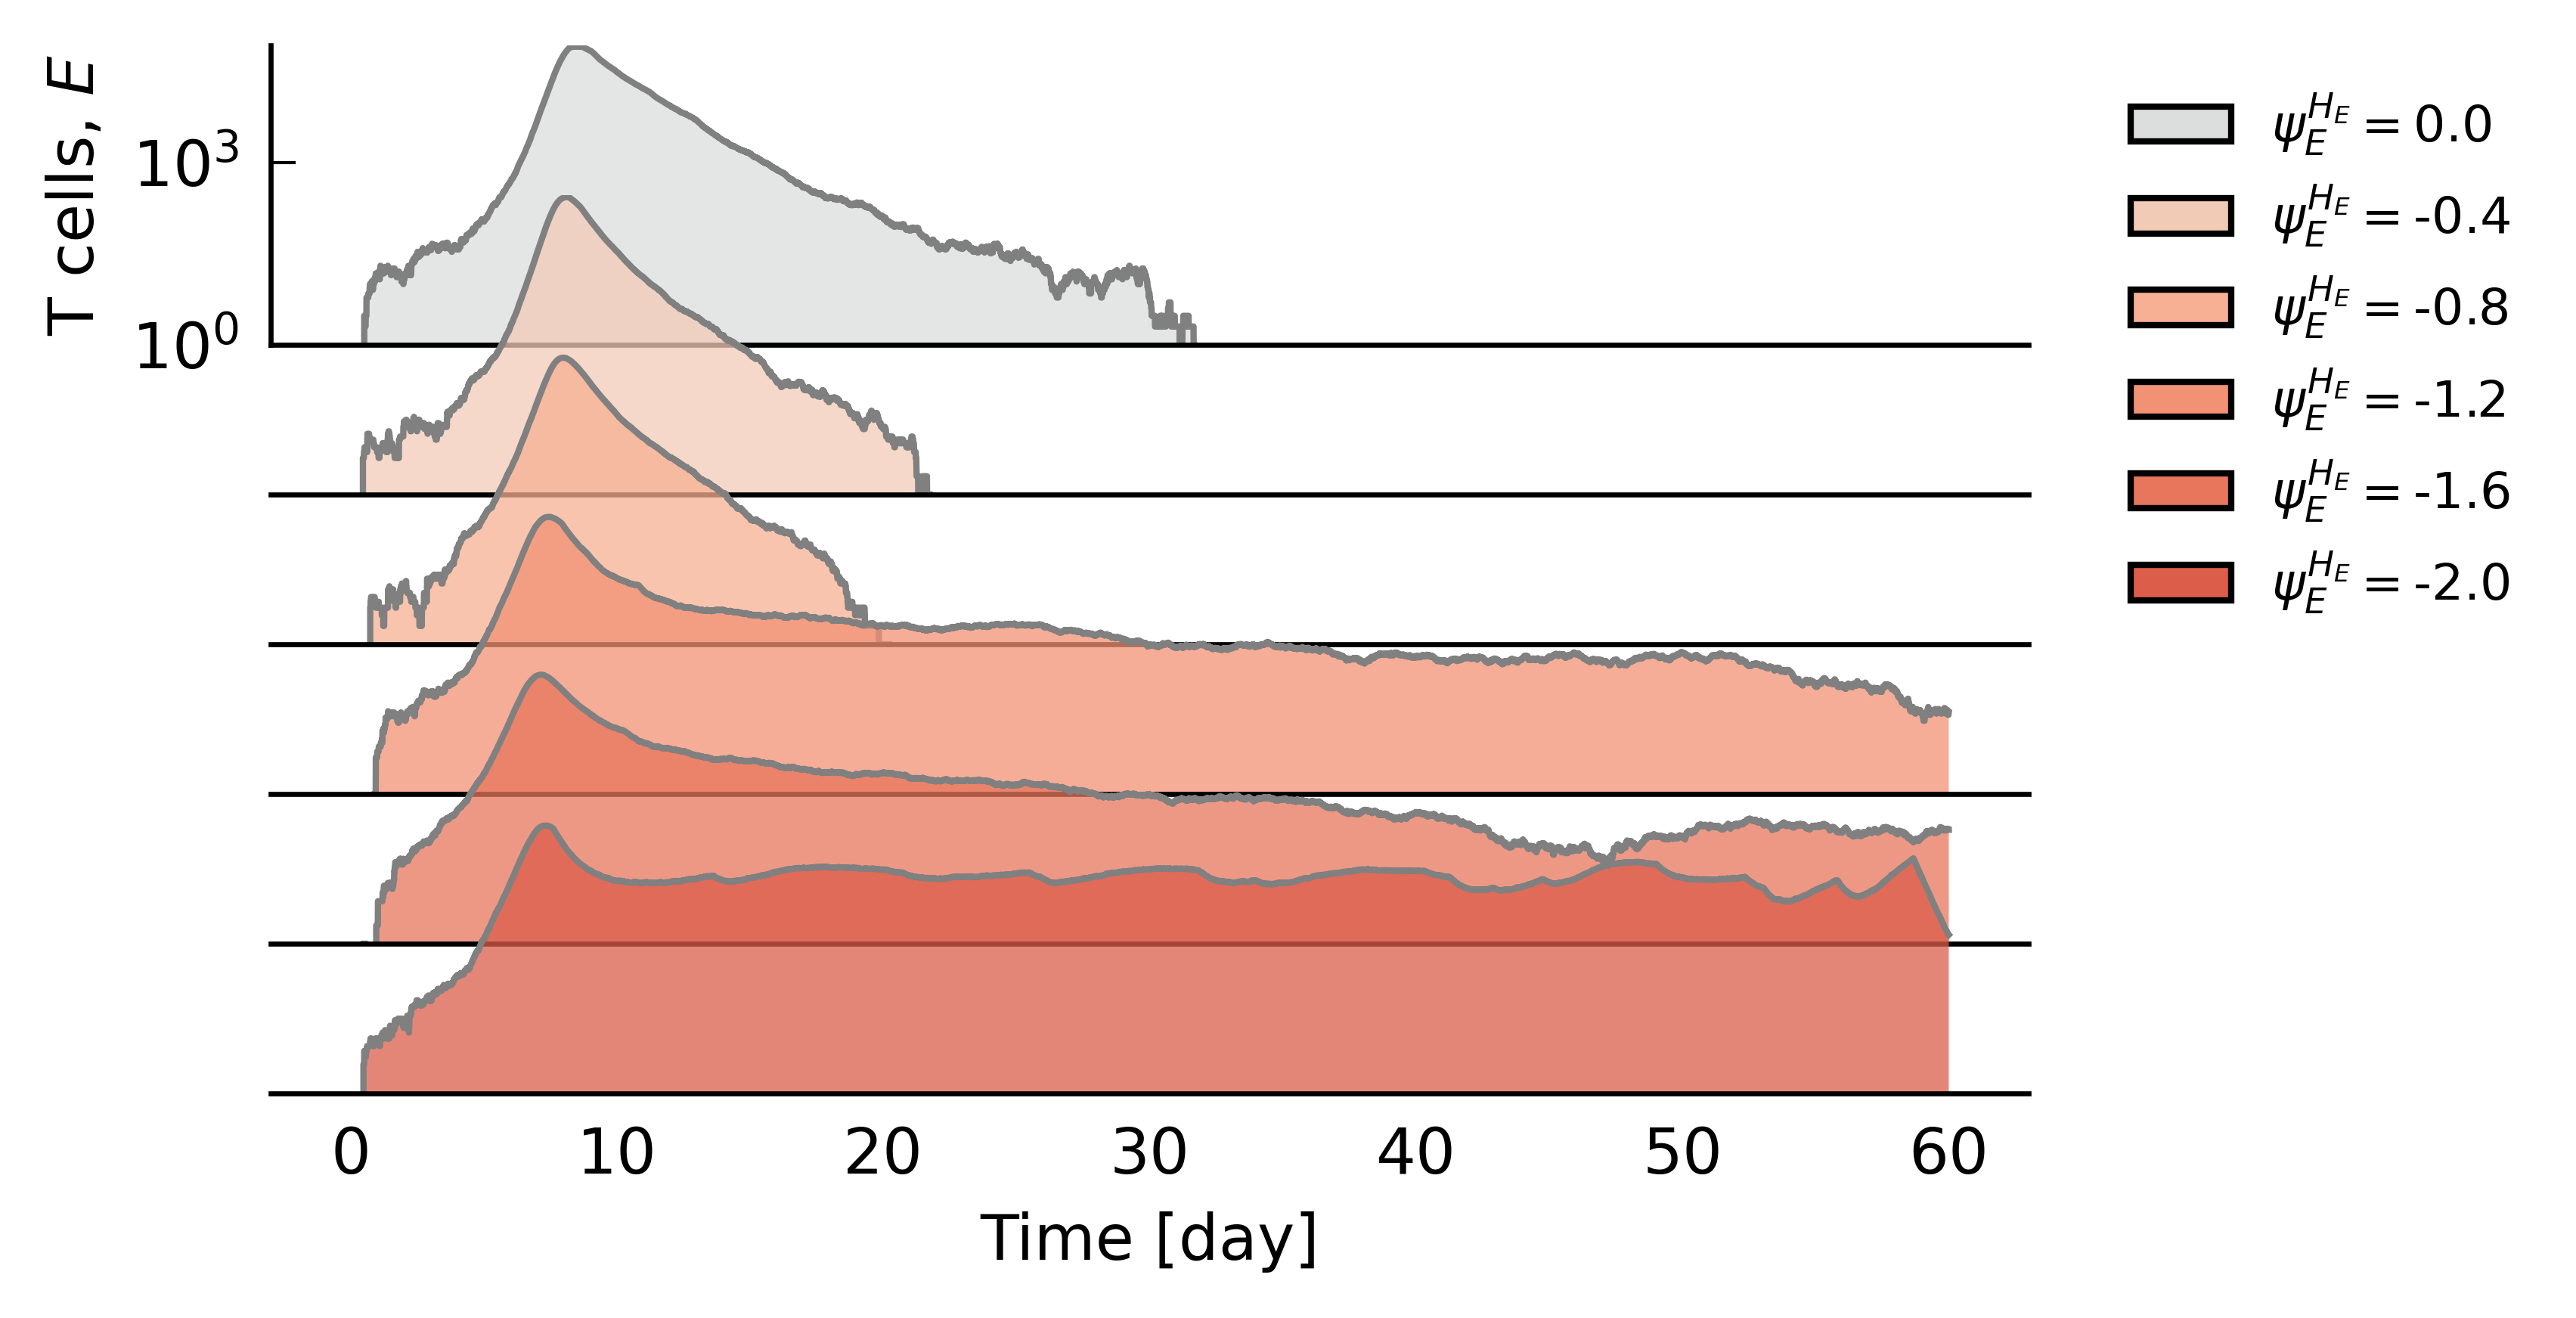

In [26]:
xs = ts


ps_HE = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.phase_cluster == 0)*(cluster_ablate_grid_opt.ablate_index == 2)*(cluster_ablate_grid_opt[opt_vars[2]] <= 0)][opt_vars[2]].tolist()[::-1]
#ps_HE = [p for k, p in enumerate(cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index == 2)][opt_vars].values[:,2])  if (k % 4 == 0)][::-1]
ys = store_Es[:len(ps_HE)][::-1]
zs = store_Is[:len(ps_HE)][::-1]

labels = [r"$\psi_E^{H_E} = $" + str(np.round(p, 1)) for p in ps_HE]

# Plotting code.
ncols = 1
nrows = len(ys)

fig, axes = plt.subplots(
    ncols=ncols, nrows=nrows, sharex=True, sharey=True, dpi=300,
    figsize=(5, 3), subplot_kw={"facecolor": (0, 0, 0, 0), "frameon": True},
    # Control how much axes overlap onto one another.
    gridspec_kw={"hspace": -0.5}, 
)

legend_handles = []

for idx, (y, ax) in enumerate(zip(ys, axes)):
    color = plt.cm.coolwarm_r(1/(1 + np.exp(-ps_HE[idx]))) #plt.colormaps["coolwarm"](idx / nrows)

    # Add black line to top of distribution.
    ax.plot(xs, y, color='grey', linewidth=1.0)
    # ax.plot(xs, zs[idx], color='k', linewidth=2.0, label = r"Infected cells, $I$" if idx == 0 else '')
    ax.set_ylim(1,None)
    ax.semilogy()
    #ax.semilogx()

    # Add black line to bottom of distribution.
    # Change min_vals to what it should be. E.g., log scale should be min_vals = 1
    min_vals = np.zeros_like(xs)
    #ax.plot(xs, min_vals, color='k', linewidth=1)

    # Create fill distributions. Alpha 
    ax.fill_between(
        xs, y, alpha=0.75, color=color, label=labels[idx],
        linewidth=0
    )
    ax.tick_params(
        right=False, top=False, left=False, bottom=False, which="both",
        # Turn off y-axis labels.
        labelleft=False
    )
    ax.spines.top.set_visible(False)
    ax.spines.left.set_visible(False)
    ax.spines.right.set_visible(False)
    ax.spines.bottom.set_visible(True)

    patch_for_legend = plt.matplotlib.patches.Patch(
        facecolor=color, edgecolor='k', label=labels[idx]
    )
    legend_handles.append(patch_for_legend)

axes[0].tick_params(bottom=True)
axes[0].spines.bottom.set_visible(True)
axes[0].tick_params(
    right=False, top=False, left=True, bottom=False, which="both",
    # Turn off y-axis labels.
    labelleft=True
)
axes[0].spines.left.set_visible(True)
axes[-1].set_xlabel("Time [day]", fontsize = 10)
axes[0].set_ylabel('T cells, '+ r'$E$', fontsize = 10)

axes[0].legend(
    handles=legend_handles, framealpha=0,
    # Adjust location of legend.
    bbox_to_anchor=(1.3, 1.0),
    fontsize=8
)

#plt.show()

plt.savefig('_figs/'+comment+'-pareto-design-ablate_prot-eff-dynamics-splines'+'.png', dpi=300, bbox_inches="tight")

In [27]:
from optimize_nets import *

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

ablate_clear_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
          ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
          -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**3 -0*ps[:,4], # EM
          -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

run(batch = [-1], outdir=d, inf_sample = cluster_input.loc[cluster_input.phase_cluster == 0, ['d_I', 'K_I', 'b_I', 'K_H', 'N_0','I_0']], 
    comment="sim_ablate_prot", runs = 10, infection_model = 'acute_ag', default_reg = ablate_clear_psis, 
    num_cpu = num_cpu, run_time = 10)

d_file = d + '/sim_batch_-1-10-acute_ag-sim_ablate_prot.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

pnts = len(np.unique(ps[:,0]))
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
ablate_prot_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names])

ablate_prot_data.loc[:, 'R_0'] = ablate_prot_data['S_0']*ablate_prot_data['b_I']/ablate_prot_data['d_I']
ablate_prot_data.loc[:,'psi_index'] = (np.array(ablate_prot_data.index.tolist()) % (len(opt_vars)*pnts))
ablate_prot_data.loc[:,'ablate_index'] = (np.array(ablate_prot_data.index.tolist()) % (len(opt_vars)*pnts)) // pnts
ablate_prot_data.loc[:,'exp_rate'] = np.log(ablate_prot_data['max_pE']/max_Na)/np.maximum(t_cycle, ablate_prot_data['T_pE_max'] - ablate_prot_data['T_pE_start'])
ablate_prot_data.loc[:,'end_rate'] = -np.log(np.maximum(ablate_prot_data['N_0'], ablate_prot_data['E_end'])/ablate_prot_data['max_pE'])/np.maximum(t_cycle, ablate_prot_data['T_pE_end'] - ablate_prot_data['T_pE_max'])
ablate_prot_data.loc[:,'max_expE'] = ablate_prot_data['max_pE']/ablate_prot_data['N_0']
ablate_prot_data.loc[:,opt_vars[0:3]] = ablate_prot_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
ablate_prot_data.loc[:,opt_vars[3:]] = 1/(1 + np.exp(-ablate_prot_data[reg_bl].values))
ablate_prot_data.loc[:,"harm_pI_noprotection"] = ablate_prot_data.apply(lambda row: np.mean(cluster_input.loc[(cluster_input[plots[0]] == row[plots[0]])*(cluster_input[plots[1]] == row[plots[1]])].harm_pI_noprotection.values), axis=1)

ablate_prot_data.loc[:,"peff_clearance"] = ablate_prot_data['harm_pI_noprotection'] - ablate_prot_data['harm_pI']/S_0
ablate_prot_data.loc[:,"peff_toxicity"] = ablate_prot_data['harm_pS']/S_0

prot_eff_dyn_design = ablate_prot_data.groupby(reg + ['ablate_index'], as_index = False, sort = False).mean()
prot_eff_dyn_design.loc[:,"peff_scaled_protection"] = (prot_eff_dyn_design['peff_clearance'] - prot_eff_dyn_design['peff_toxicity'])/prot_eff_dyn_design["harm_pI_noprotection"]

# with pd.option_context('display.max_columns', None):
#     display(prot_eff_dyn_design)

Running 32340 simulations in batch #-1
Saved sim_batch_-1-10-acute_ag-sim_ablate_prot.pkl
0.14257581684324477 hrs


/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


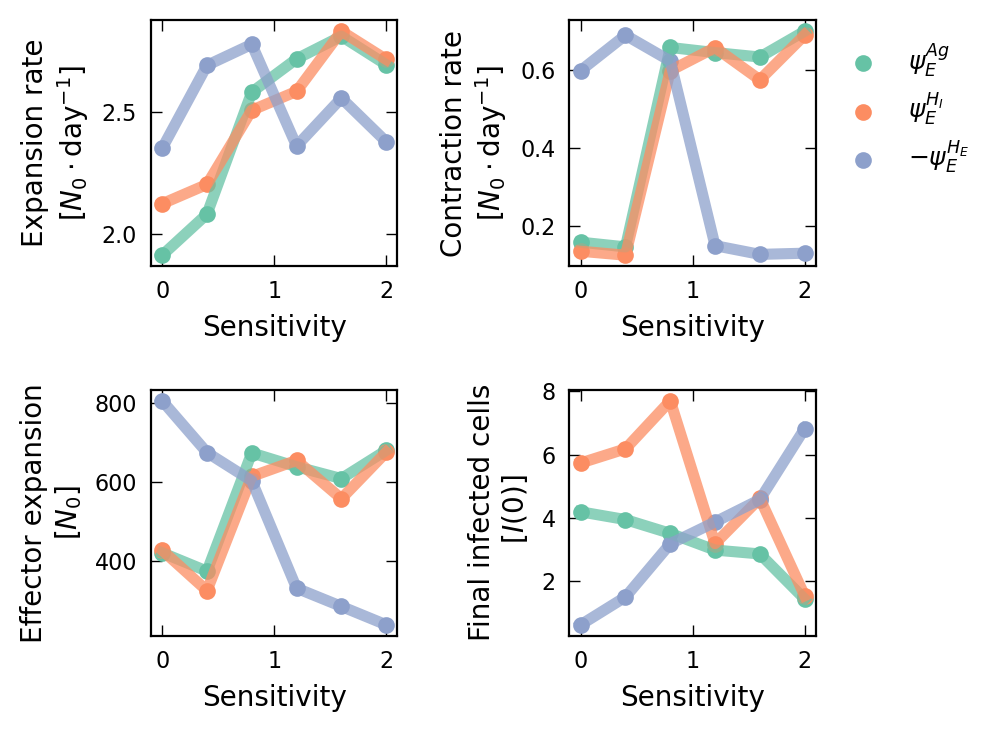

In [42]:
# Plot dependency of effector dynamics on design
eff_dyn_vars = ['exp_rate', 'end_rate', 'max_expE', 'p_load'] # 'exp_rate', , 'sel_ratio'
eff_dyn_labels = ['Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Contraction rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 
                  'Effector expansion\n'+ r'[$N_0$]', 'Final infected cells'+'\n [$I(0)$]'] # 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', , 'Response avidity'

# Make trade-off figure
fig, axs = plt.subplots(2, 2,figsize=(4.5, 4), sharex='row', sharey=False) #,layout='constrained')

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, (eff_var, ax) in enumerate(zip(eff_dyn_vars, axs.flat)):

    # (a) Effect of single parameter ablation on protection
    for i, var in enumerate(opt_vars[0:3]):
        plot_data = prot_eff_dyn_design.loc[(prot_eff_dyn_design.ablate_index == i)*(prot_eff_dyn_design[var] >=0 if i <=1 else prot_eff_dyn_design[var] <=0)]
        
        ax.plot(np.abs(plot_data[var].values),
                plot_data[eff_var].values,
                color = cmap_colors[i], 
                            **kwargs)

        ax.scatter(np.abs(plot_data[var].values),
                   plot_data[eff_var].values,
                   label = (r"$-$" if i == 2 else '')+opt_vars_labels[i],
                   color = cmap_colors[i])
        
    if k == 1:
        ax.legend(bbox_to_anchor=(1.0, 1), fontsize=9, framealpha=0, ncol = 1)
    
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    ax.locator_params(axis='x', nbins=4)
    if 'exp.' not in eff_dyn_labels[k]:
        ax.locator_params(axis='y', nbins=4)
    else:
        ax.semilogy()

    ax.minorticks_off()
    #ax.set_ylim(0, None)
    ax.set_ylabel(eff_dyn_labels[k], fontsize = 10)
    ax.set_xlabel("Sensitivity", fontsize = 10)

# Store critical regulatory design
acute_crit_reg_index = np.argmax(prot_eff_dyn_design.loc[(prot_eff_dyn_design.ablate_index == 2), ['peff_scaled_protection']].values)
acute_crit_reg = prot_eff_dyn_design.loc[(prot_eff_dyn_design.ablate_index == 2), opt_vars[0:3] + reg_bl].values[acute_crit_reg_index]
    
fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/'+comment+'-pareto-design-ablate_prot-eff-dynamics-simple'+'.png', dpi=300, bbox_inches="tight")

The strong negative effect of down-regulation with the anti-inflammatory signal is a strong argument for why it may be in the regime of weak regulation. In some ways the anti-inflammatory signal can be auto-regulatory.

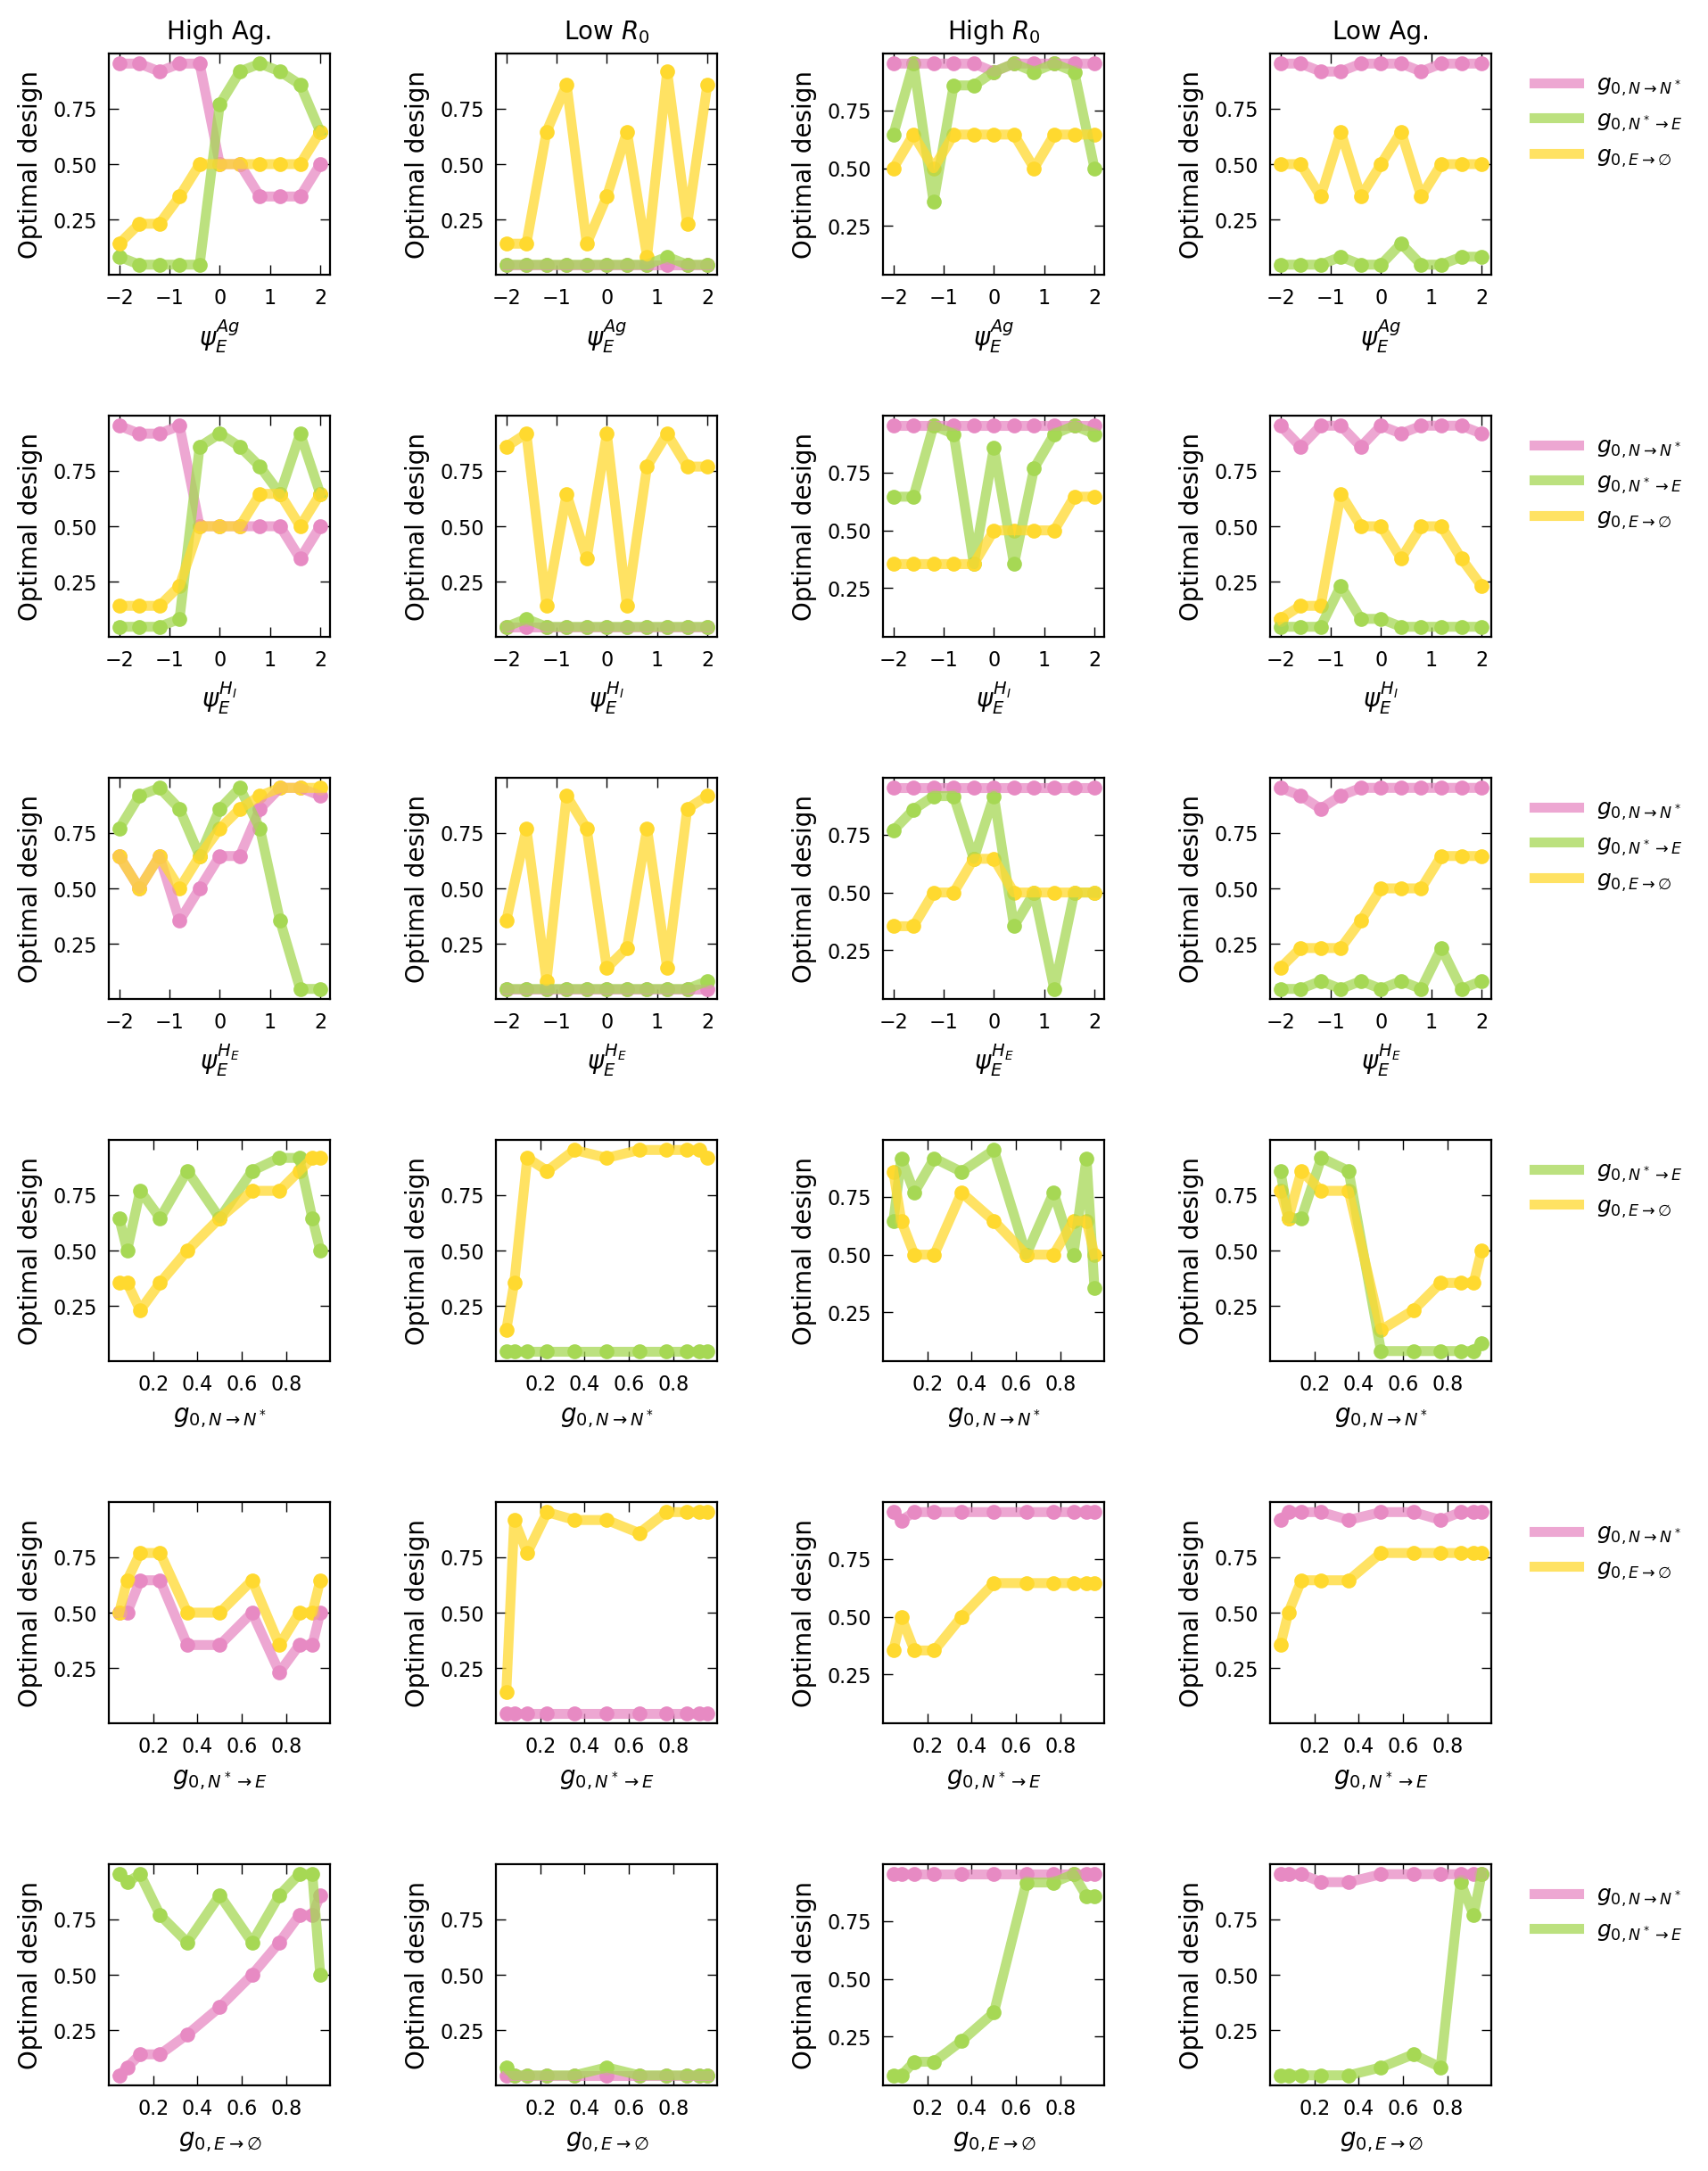

In [29]:
# Make trade-off figure
fig, axs = plt.subplots(len(opt_vars), n_clusters,figsize=(2.5*n_clusters, 2.5*len(opt_vars)), sharex='row', sharey='col') #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on clearance
    for i, var in enumerate(opt_vars):
        for j, u in enumerate(opt_vars):
            if i !=j and j > 2:
                axs[i,k].plot(g.loc[(g.ablate_index == i), var].values,
                                g.loc[(g.ablate_index == i), u].values,
                         color = cmap_colors[j], 
                                label = opt_vars_labels[j],
                                # linestyle = linestyles[j],
                                **kwargs)

                axs[i,k].scatter(g.loc[(g.ablate_index == i), var].values,
                                g.loc[(g.ablate_index == i), u].values,
                 color = cmap_colors[j])

        axs[i,k].set_xlabel(opt_vars_labels[i], fontsize = 10)

        #axs[i,k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
        if k == n_clusters - 1:
            axs[i,-1].legend(bbox_to_anchor=(1.1, 1), fontsize=9, framealpha=0, ncol = 1)
        
    axs[0,k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=6)
    ax.set_ylabel("Optimal design", fontsize = 10)

fig.subplots_adjust(wspace=.75, hspace=0.45)

plt.savefig('_figs/'+comment+'-pareto-prot_ablate_feedback_designs'+'.png', dpi=300, bbox_inches="tight")

Also, plot performance of optimal acute response designs while varying anti-inflammatory sensitivity, along with the performance of these same designs in other scenarios. Probably want to normalize protection by clearance.

In [30]:
# Compute design performance in each cluster
avg_cluster_data = cluster_sim_df.groupby(opt_vars + ['phase_cluster'], as_index = False).mean()

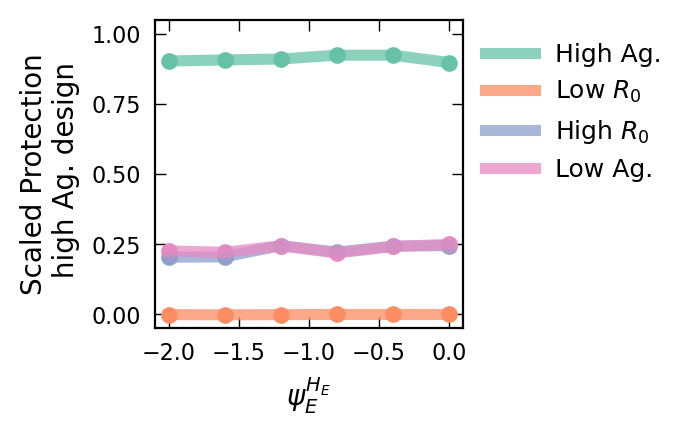

In [31]:
# Visualize pareto regulation
perf = 0

fig, axs = plt.subplots(1, 1,figsize=(2, 2), sharex='row', sharey='col') #,layout='constrained')

ref_group = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)*(cluster_ablate_grid_opt.ablate_index == 2)*(cluster_ablate_grid_opt.phase_cluster == 0)*(cluster_ablate_grid_opt[opt_vars[2]] <= 0)]

for k, (_, g) in enumerate(avg_cluster_data.groupby(['phase_cluster'])):
    # (a) Effect of H_E ablation on protection
    plot_data = ref_group.merge(g[opt_vars + perf_vars + ['peff_protection', 'harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

    axs.plot(plot_data[opt_vars[2]], plot_data['peff_protection_comp'].values/plot_data['harm_pI_noprotection'].values,
         color = cluster_colors[k],
         label = phase_cluster_labels[k],
                        **kwargs)

    axs.scatter(plot_data[opt_vars[2]], 
                plot_data['peff_protection_comp'].values/plot_data['harm_pI_noprotection'].values,
                 color = cluster_colors[k])

axs.legend(bbox_to_anchor=(1.0, 1), fontsize=9, framealpha=0, ncol = 1)
axs.minorticks_off()
axs.set_box_aspect(1)
axs.tick_params(axis='both', which='major', labelsize=8)
axs.locator_params(axis='y', nbins=5)
axs.locator_params(axis='x', nbins=5)
axs.set_ylabel(r"Scaled Protection"+"\n high Ag. design", fontsize = 10)
axs.set_xlabel(opt_vars_labels[2], fontsize = 10)
axs.set_ylim(None,1.05)
axs.xaxis.set_tick_params(labelbottom=True)
axs.yaxis.set_tick_params(labelleft=True)

plt.savefig('_figs/'+comment+'-pareto-prot_compare_phases_ablate_feedback'+'.png', dpi=300, bbox_inches="tight")

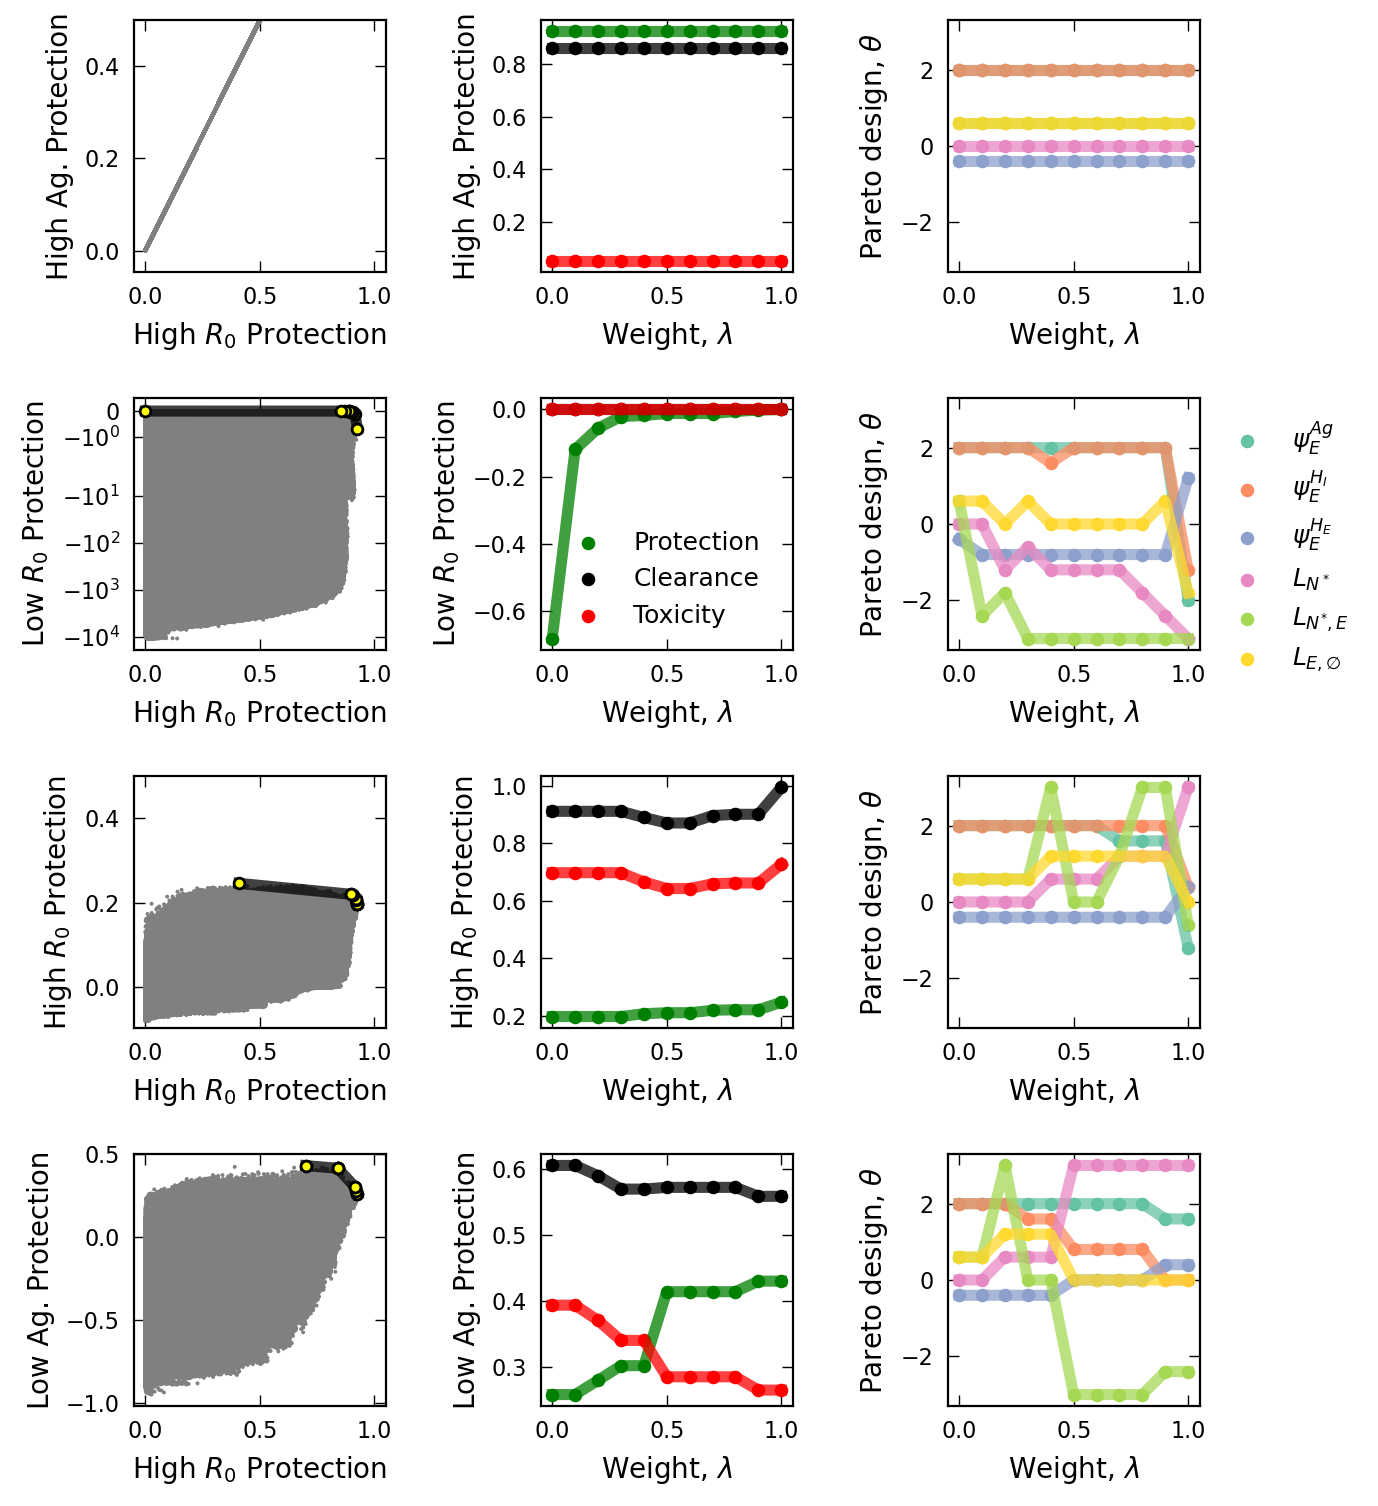

In [32]:
# Visualize pareto regulation
perf = 0

fig, axs = plt.subplots(n_clusters, 3, figsize=(7, 9), sharex=False, sharey=False) #,layout='constrained')

ref_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 0)]
lambdas = np.linspace(0,1, 11)

for k, (_, g) in enumerate(avg_cluster_data.groupby(['phase_cluster'])):
    # (a) Effect of H_E ablation on protection
    plot_data = ref_group.loc[ref_group.peff_scaled_protection > 0].merge(g[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

    # im = axs[k, 0].hexbin(plot_data['peff_scaled_protection'].values, 
    #                    plot_data['peff_scaled_protection_comp'].values,
    #                    gridsize = 50,
    #                    C = None,
    #                    cmap='Purples', edgecolors = 'None',
    #                    norm = mpl.colors.LogNorm())

    im = axs[k,0].scatter(plot_data['peff_scaled_protection'].values, 
                          plot_data['peff_scaled_protection_comp'].values,
                          s = 2, color = "gray",
                          #c = plot_data[opt_vars[2]], cmap='Purples', 
                          edgecolors = 'None')

    axs[1,0].set_yscale('symlog')
    axs[k,0].set_ylim(None,0.5)

    pareto_designs = []

    # In
    for l in lambdas:
        pareto_index = np.argmax((1 - l)*plot_data['peff_scaled_protection'].values + l*plot_data['peff_scaled_protection_comp'].values)

        pareto_designs.append(plot_data.loc[pareto_index])

    pareto_design_df = pd.concat(pareto_designs)

    axs[k,0].plot(pareto_design_df['peff_scaled_protection'].values, 
                  pareto_design_df['peff_scaled_protection_comp'].values,
                  color='black',
             **kwargs)
    
    axs[k,0].scatter(pareto_design_df['peff_scaled_protection'].values, 
                     pareto_design_df['peff_scaled_protection_comp'].values,
           s = 15,
           color='yellow', edgecolors = 'black', zorder = 2)

    for l, perf in enumerate(perf_vars[0:3]):
        axs[k,1].plot(lambdas,
                      pareto_design_df[perf+'_comp'].values,
                      color = perf_var_colors[l],
                      **kwargs)
        
        axs[k,1].scatter(lambdas,
                         pareto_design_df[perf+'_comp'].values,
                         color = perf_var_colors[l],
                         s = 15,
                         label = perf_labels[l])

    for i, var in enumerate(opt_vars[0:3] + reg_bl):
        axs[k,2].plot(lambdas,
                      pareto_design_df[var].values,
                      color = cmap_colors[i], 
                                **kwargs)
        axs[k,2].scatter(lambdas,
                         pareto_design_df[var].values,
                         label = (opt_vars_labels[0:3] + reg_bl_label)[i],
                         s = 15,
                         color = cmap_colors[i])

    axs[k,0].set_ylabel(phase_cluster_labels[k] + ' Protection', fontsize = 10)
    axs[k,0].set_xlabel(phase_cluster_labels[2] + ' Protection', fontsize = 10)
    
    axs[k,1].set_xlabel(r"Weight, $\lambda$", fontsize = 10)
    axs[k,1].set_ylabel(phase_cluster_labels[k] + ' Protection', fontsize = 10)

    axs[k,2].set_xlabel("Weight, $\lambda$", fontsize = 10)
    axs[k,2].set_ylabel(r"Pareto design, $\theta$", fontsize = 10)
    axs[k,2].set_ylim(-1.1*L0_max, 1.1*L0_max)

axs[1,1].legend(fontsize=9, framealpha=0, ncol = 1)
axs[1,2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=9)

for ax in axs.flat:
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    #ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    #ax.set_ylim(None, 0.5)
    ax.set_xlim(-0.05, 1.05)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/'+comment+'-pareto-prot_compare_phases_ablate_feedback'+'.png', dpi=300, bbox_inches="tight")

A strong antigen response causes a lot of toxicity when applied to a weak antigen. But the response can be adjusted.

/tmp/ipykernel_77226/3437370767.py:34: RuntimeWarning: invalid value encountered in divide
  pareto_index = np.argmax(-(1 - l)*plot_data['max_pE_comp'].values/np.amax(plot_data['max_pE_comp'].values) + l*plot_data['peff_scaled_protection_comp'].values/np.amax(plot_data['peff_scaled_protection_comp'].values))
/tmp/ipykernel_77226/3437370767.py:34: RuntimeWarning: divide by zero encountered in divide
  pareto_index = np.argmax(-(1 - l)*plot_data['max_pE_comp'].values/np.amax(plot_data['max_pE_comp'].values) + l*plot_data['peff_scaled_protection_comp'].values/np.amax(plot_data['peff_scaled_protection_comp'].values))


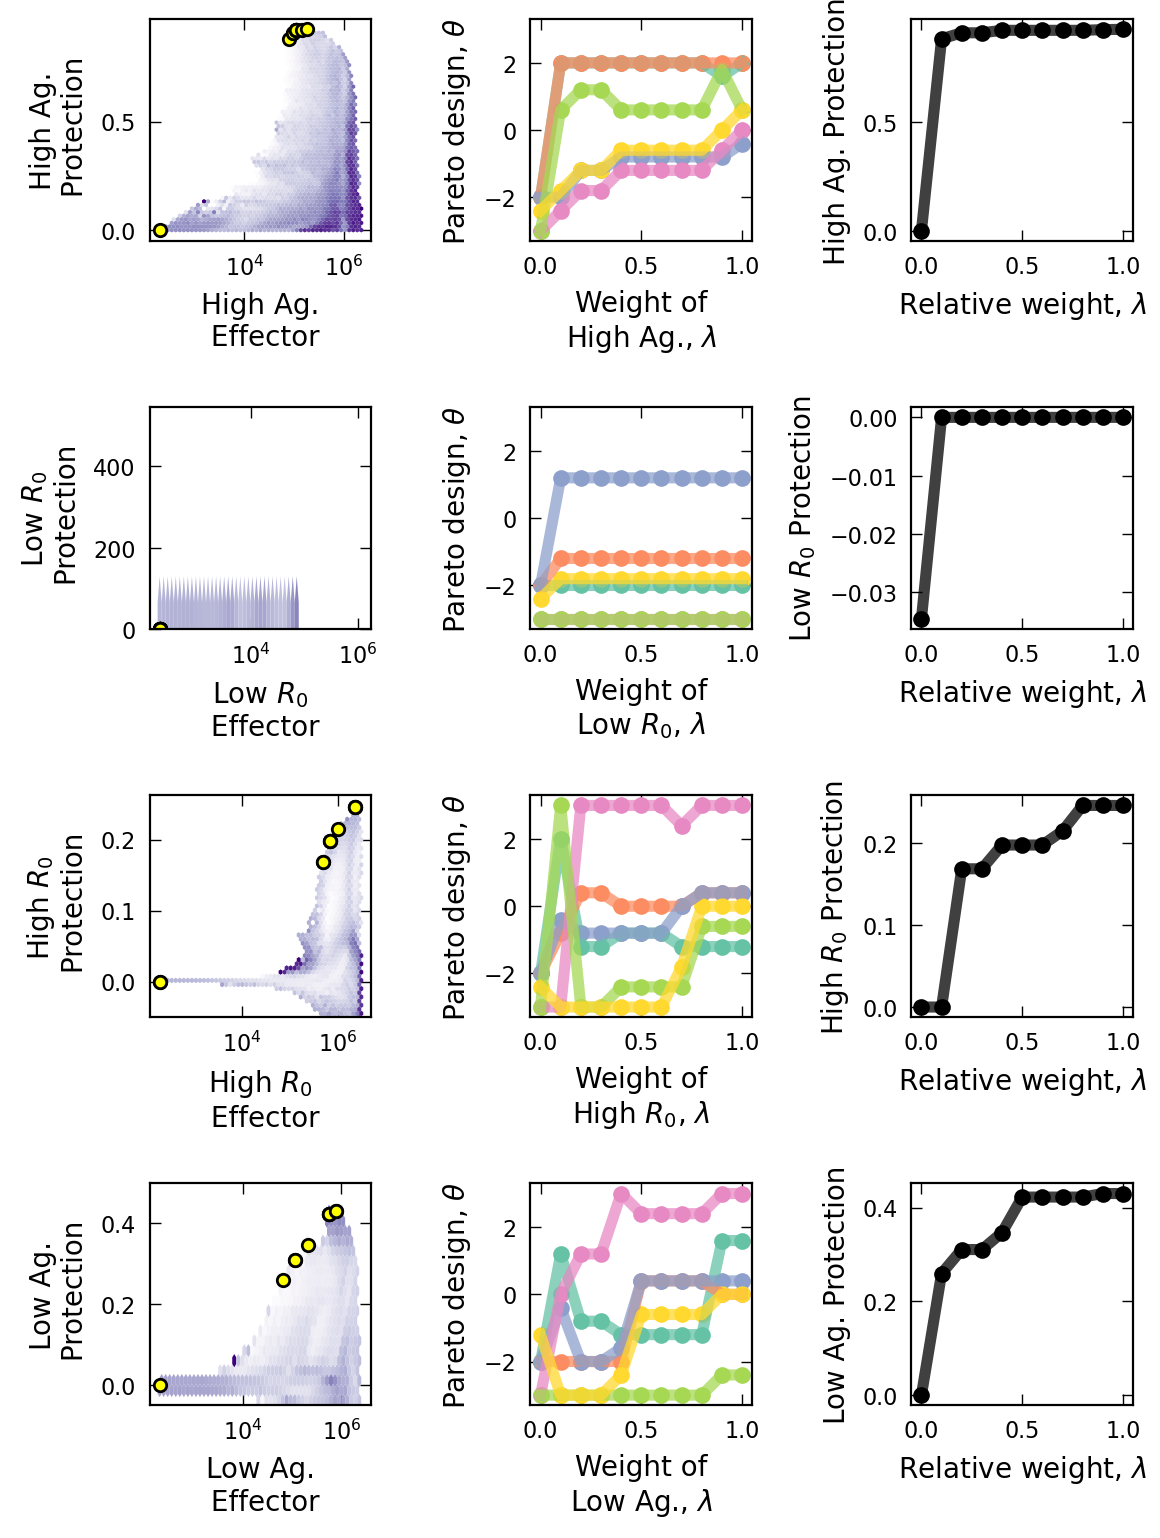

In [33]:
# Visualize pareto regulation
perf = 0

fig, axs = plt.subplots(n_clusters, 3, figsize=(6.5, 9), sharex=False, sharey=False) #,layout='constrained')

ref_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 0)]
lambdas = np.linspace(0,1, 11)

for k, (_, g) in enumerate(avg_cluster_data.groupby(['phase_cluster'])):
    # (a) Effect of H_E ablation on protection
    plot_data = ref_group.loc[ref_group.peff_scaled_protection > 0].merge(g[opt_vars + perf_vars + ['max_pE', 'harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

    im = axs[k, 0].hexbin(plot_data['max_pE_comp'].values, 
                       plot_data['peff_scaled_protection_comp'].values,
                       gridsize = 50, xscale ='log',
                       C = plot_data[opt_vars[2]],
                       cmap='Purples', edgecolors = 'None',
                       norm = mpl.colors.Normalize())

    # im = axs[k,0].scatter(plot_data['max_pE_comp'].values, 
    #                plot_data['peff_scaled_protection_comp'].values,
    #                s = 5,
    #                c = plot_data[opt_vars[2]],
    #                cmap='coolwarm_r', edgecolors = 'None')

    # axs[k,0].semilogx()

    axs[k,0].set_ylim(-0.05,None)

    pareto_designs = []

    # In
    for l in lambdas:
        pareto_index = np.argmax(-(1 - l)*plot_data['max_pE_comp'].values/np.amax(plot_data['max_pE_comp'].values) + l*plot_data['peff_scaled_protection_comp'].values/np.amax(plot_data['peff_scaled_protection_comp'].values))

        pareto_designs.append(plot_data.loc[pareto_index])

    pareto_design_df = pd.concat(pareto_designs)

    # axs[k,0].plot(pareto_design_df['max_pE_comp'].values, 
    #               pareto_design_df['peff_scaled_protection_comp'].values,
    #               color='black',
    #          **kwargs)
    
    axs[k,0].scatter(pareto_design_df['max_pE_comp'].values, 
                     pareto_design_df['peff_scaled_protection_comp'].values,
           s = 20,
           color='yellow', edgecolors = 'black', zorder = 2)

    for i, var in enumerate(opt_vars[0:3] + reg_bl):
        axs[k,1].plot(lambdas,
                      pareto_design_df[var].values,
                      color = cmap_colors[i], 
                      label = (opt_vars_labels[0:3] + reg_bl_label)[i],
                                **kwargs)
        axs[k,1].scatter(lambdas,
              pareto_design_df[var].values,
              color = cmap_colors[i])

    axs[k,2].plot(lambdas,
                  pareto_design_df['peff_scaled_protection_comp'].values,
                  color = 'k',
                  **kwargs)
    
    axs[k,2].scatter(lambdas,
                     pareto_design_df['peff_scaled_protection_comp'].values,
                     color = 'k')

    axs[k,0].set_ylabel(phase_cluster_labels[k] + '\n Protection', fontsize = 10)
    axs[k,0].set_xlabel(phase_cluster_labels[k] + '\n Effector', fontsize = 10)

    axs[k,1].set_xlabel("Weight of\n"+ phase_cluster_labels[k] + r', $\lambda$', fontsize = 10)
    axs[k,1].set_ylabel(r"Pareto design, $\theta$", fontsize = 10)
    axs[k,1].set_ylim(-1.1*L0_max, 1.1*L0_max)


    axs[k,2].set_xlabel(r"Relative weight, $\lambda$", fontsize = 10)
    axs[k,2].set_ylabel(phase_cluster_labels[k] + ' Protection', fontsize = 10)
                        
for ax in axs.flat:
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    #ax.locator_params(axis='x', nbins=4)
    # ax.set_ylim(0,None)
    #ax.set_xlim(-0.05, 1.05)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.55, hspace=0.75)

#plt.savefig('_figs/'+comment+'-pareto-prot_compare_phases_ablate_feedback'+'.png', dpi=300, bbox_inches="tight")

Optimal designs switch between modes of clearance and containment of the infection. How can I show this more suscinctly? Maybe focus on the time it takes for the infection to clear? Maybe sample design space and do clustering/low dimensional embedding of the 4 effector dynamics variables and then look within those clusters?

Maybe only relevant when we focus in on the anti-inflammatory feedback and the naive to effector pathway for Ag. dominant infections. This figure is about trade-offs.

#### Application to a model of a fast-growing tumor

In [34]:
# Define variables and dataframes
cancer_plots = [vir_vars[1], vir_vars[0], vir_vars[4]]
cancer_plot_labels = ["Antigenicity", "Dosage"]

cancers_labels = ['Lower ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1]]

cancers_labels_indent = ['Lower ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1]]

In [35]:
def choose_continous_color(x, color):
    if color == 0:
        out = plt.cm.Greys(x)
    elif color == 1:
        out = plt.cm.Blues(x)
    elif color == 2:
        out = plt.cm.Reds(x)

    return out

There a sort of goldilocks effect where the designs for cancer protection are suboptimal for acute response but the worst designs those of intermediate antigenicity.

##### Compute tumour protection of Ag. dominant pareto protection

In [36]:
from optimize_nets import *
num_pnts = 15
runs = 40
sample = np.array(np.meshgrid(d_S*np.array([1.0]), # vary d_I
                                   S_0*np.logspace(-2.0, 0.0, num_pnts), # vary K_I
                                   b_C*np.array([1.0]), # vary b_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-2.0, 0.0, num_pnts), # vary N_0
                                   S_0*np.array([0.1]) # vary I_0
                                           )).T.reshape(-1,6)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

h = 1e-1
arr = np.arange(0, len(acute_crit_reg))
ps = np.vstack([[acute_crit_reg - h*(arr == j), acute_crit_reg, acute_crit_reg + h*(arr == j)] for j, a in enumerate(arr)])
cancer_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
          ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
          -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**3 -0*ps[:,4], # EM
          -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
# run(batch = [-1], outdir=d, inf_sample = sample, 
#     comment="cancer_acute_comp_sim", runs = runs, infection_model = '', 
#     default_reg = cancer_psis,
#     num_cpu = num_cpu)

In [37]:
d_file = d + '/sim_batch_-1-40--cancer_acute_comp_sim.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(cancer_plots + reg, as_index=False).mean()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = sample[0][5], K_I = K_I, d_I = sample[0][0], b_I = sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_0
cancer_acute_comp_df.loc[:,"peff_clearance"] = (no_eff_stats[3] - cancer_acute_comp_df['harm_pI'].to_numpy())/S_0
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_protection"] = (cancer_acute_comp_df['peff_clearance'] - cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_protection"] = cancer_acute_comp_df['peff_protection']/cancer_acute_comp_df['harm_pI_noprotection']

In [38]:
# Find optimal dosage for each antigenicity
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - acute_crit_reg), axis = 1) == 0]
opt_N0 = data.loc[data.groupby('K_I')['peff_scaled_protection'].idxmax()].copy()
data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.median(data['N_0'].values))
fixed_N0 = data.loc[data.groupby('K_I')['N_0_match'].idxmin()].copy() #np.amax(data['N_0'])

# Compute effect of perturbation in the design
gradients = []
for k, (a,b) in enumerate(fixed_N0[['K_I', 'N_0']].values):
    input = cancer_acute_comp_df.loc[(cancer_acute_comp_df.K_I == a)*(cancer_acute_comp_df.N_0 == b)].copy()
    input.loc[:,'dummy'] = np.sum(np.abs(input.copy()[opt_vars[0:3] + reg_bl].values - acute_crit_reg), axis = 1)
    out = np.zeros(len(opt_vars[0:3] + reg_bl))
    for i, var in enumerate(opt_vars[0:3] + reg_bl):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_scaled_protection.values
        grad = np.gradient(f, h)
        out[i] += grad[1]

    gradients.append(out)

gradients_data = np.vstack(gradients)

/tmp/ipykernel_77226/976334025.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.median(data['N_0'].values))


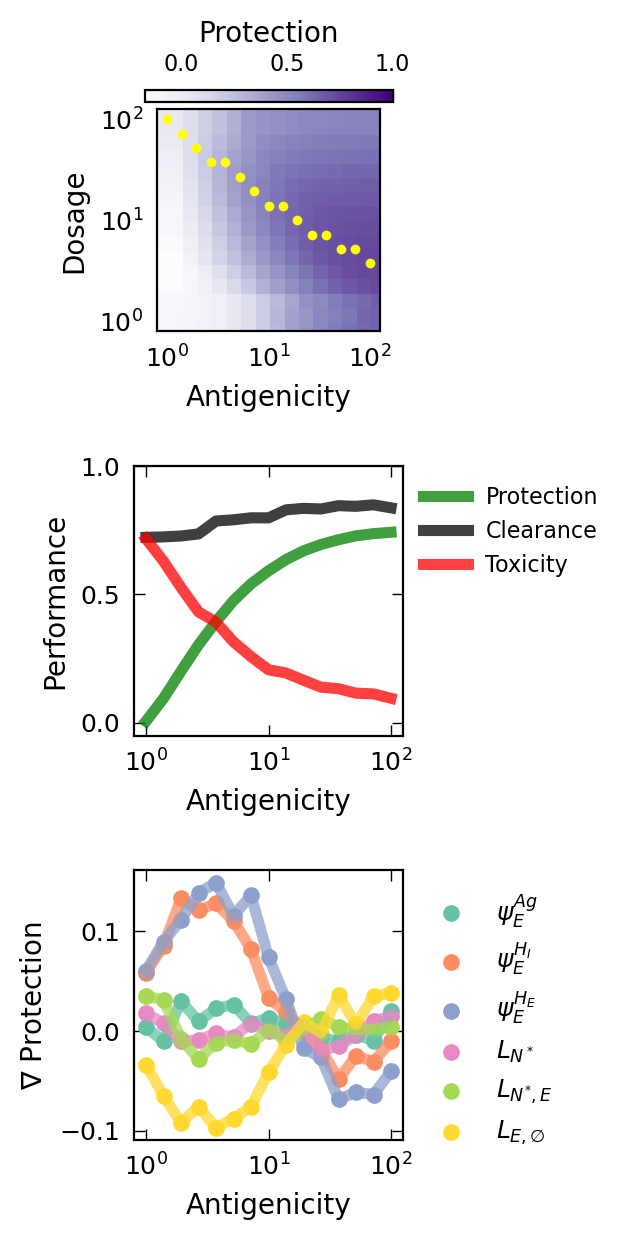

In [39]:
fig, axs = plt.subplots(3, 1, figsize=(2, 7), sharex=False, sharey=False)

size = 2000/num_pnts
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - acute_crit_reg), axis = 1) == 0]
im = axs[0].scatter(data['S_0'].values/data['K_I'].values,
                 data['N_0'].values, #/data['S_0'].values,
                 marker = 's', s = size,
                 c = data['peff_scaled_protection'].values, 
                 cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

axs[0].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['N_0'].values, #/opt_N0['S_0'].values,
         color = 'yellow', marker = '.')

axs[1].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['peff_scaled_protection'].values,
         color = 'green', label = "Protection",
           **kwargs)

axs[1].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['peff_clearance'].values/opt_N0['harm_pI_noprotection'].values,
         color = 'black', label = perf_labels[1],
           **kwargs)

axs[1].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['peff_toxicity'].values/opt_N0['harm_pI_noprotection'].values,
         color = 'red', label = perf_labels[2],
           **kwargs)

axs[1].set_ylabel("Performance", fontsize = 10)
axs[1].set_ylim(-0.05, 1.0)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(bbox_to_anchor=(1.0, 1),fontsize = 8)

for i, var in enumerate(opt_vars_labels):
    axs[2].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
                gradients_data[:,i],
                color = cmap_colors[i], 
                #linestyle = linestyles[i],
                **kwargs)

    axs[2].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
                gradients_data[:,i],
                   label = (opt_vars_labels[0:3] + reg_bl_label)[i],
                color = cmap_colors[i])

axs[2].set_ylabel(r"$\nabla$"+" Protection", fontsize = 10)
axs[2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=9)
#axs[2].set_ylim(-1.1*np.amax(np.abs(gradients_data)), 1.1*np.amax(np.abs(gradients_data)))
    

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=9)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = "Protection"
cb = fig.colorbar(im, ax=axs[0], location='top', shrink = 0.8, pad = 0.025)
cb.set_label(z_label, fontsize = 10)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.0, hspace=0.5)

plt.savefig('_figs/'+comment+'-reg-_compare_acute_prot_w_cancer_pareto_design'+'.png', dpi=300, bbox_inches="tight")

The net clearance is too high.

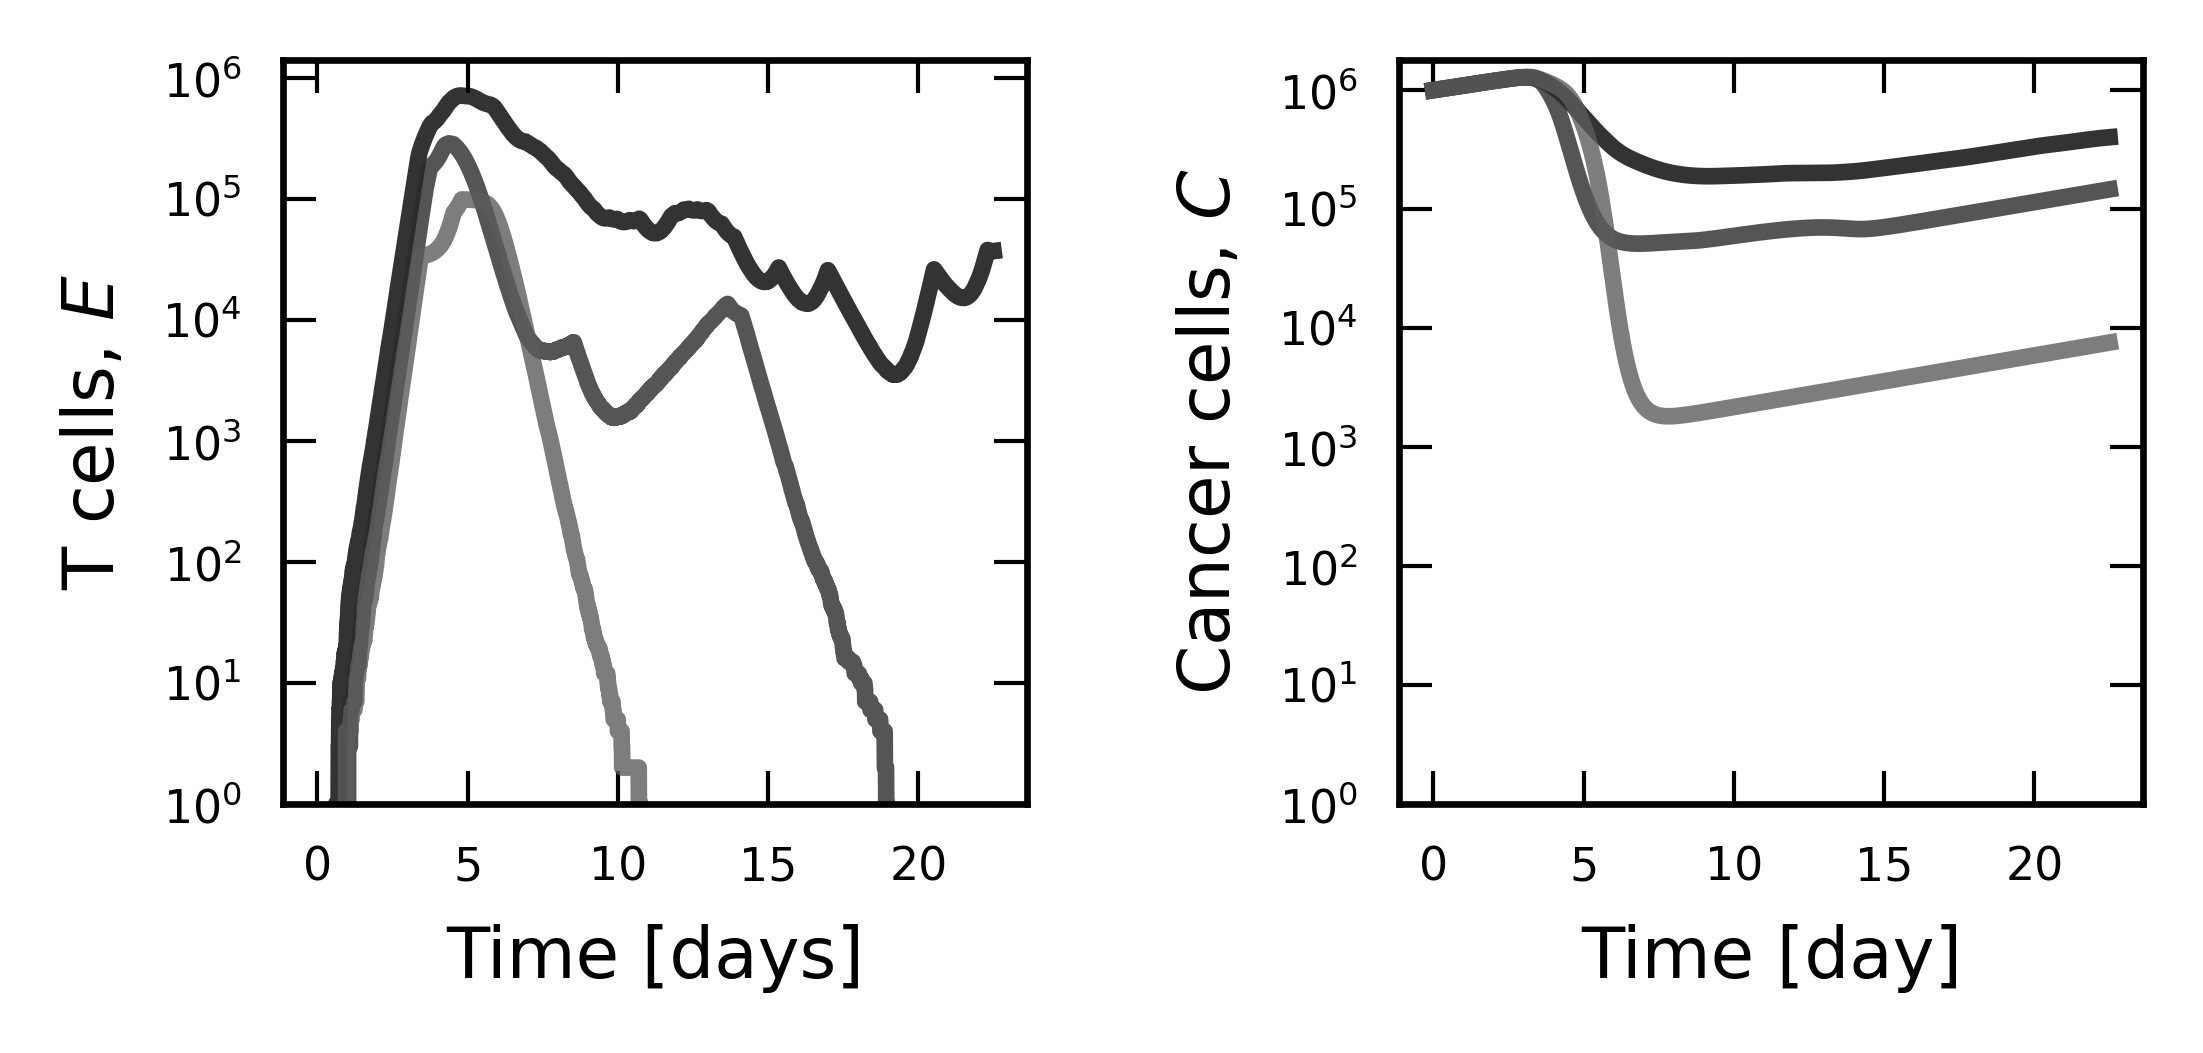

In [40]:
# Plot select infection responses
fig, axs = plt.subplots(1,2, dpi = 300, sharex = False, sharey = False, figsize=(4, 2))

sample = opt_N0[vir_vars].sort_values(by=cancer_plots[0], 
                                      ascending = [False]).values[[0, num_pnts // 2, -1],:]

store_runs = []
# Loop and do 
for k, v in enumerate(sample):

    feedback = p[-1]
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[6],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              K_S = v[5],
                              NE_regulation = [acute_crit_reg[0], acute_crit_reg[1], acute_crit_reg[2], acute_crit_reg[4]],
                              activation_regulation = [acute_crit_reg[0], acute_crit_reg[1], acute_crit_reg[2], acute_crit_reg[3]],
                              contraction_regulation = [-acute_crit_reg[0], -acute_crit_reg[1], -acute_crit_reg[2], acute_crit_reg[5]],
                              infection_model = 'cancer',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 0.75*sim_duration,
                              steps = 1.0*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0].plot(ts, E, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_0))), alpha = 0.8)
    axs[1].plot(ts, I, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_0))), alpha = 0.8)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j == 0:
        ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [days]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    elif j == 1:
        ax.set_ylabel(r'Cancer cells, $C$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    else:
        ax.set_xlabel("Antigenicity", fontsize = 8.5)
        #ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector observable", fontsize = 8.5)
        #ax.set_yscale('symlog')
        # ax.semilogy()
        ax.semilogx()

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-design-cancer_prot-eff-dynamics'+'.png', dpi=300, bbox_inches="tight")

Focusing on anti-inflammatory feedback, the optimal designs for acute response perform best with a treatment of high antigenicity and low dosage. What does this look like dynamically?

Fixing a pareto optimal network (with acute design) and varying one of the parameters we find that the biggest impact on performance in the biologically plausible range of inflammatory feedback comes from increasing/decreasing the inflammatory signal and/or the Naive to effector transition baseline. This suggests that if cancer can hide it's inflamatory signals it will be harder to clear.